In [82]:
import pandas as pd
salaries = pd.read_csv('salaries.csv')
salaries.tail()
salaries.shape

(105434, 11)

In [83]:
import janitor

In [84]:
salaries.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EN,FT,Data Analist,65664,EUR,69120,NL,0,NL,M
1,2025,EN,FT,Data Analist,47652,EUR,50160,NL,0,NL,M
2,2025,EN,FT,Data Engineer,158113,USD,158113,US,0,US,M
3,2025,EN,FT,Data Engineer,87795,USD,87795,US,0,US,M
4,2025,EX,FT,Data Engineer,351410,USD,351410,US,0,US,M


## Comparing and Predicting the Average Annual Salaries of Data Scientists in Africa, Asia, North America, and Europe
## Descriptive Analysis and Predictive modelling

In [85]:
# checking for duplicates
salaries.duplicated().sum()

np.int64(52997)

In [86]:
# Drop exact duplicates (keeps the first occurrence by default)
salaries2 = salaries.drop_duplicates()

print(f"Original shape: {salaries.shape}, Cleaned shape: {salaries2.shape}")

Original shape: (105434, 11), Cleaned shape: (52437, 11)


In [87]:
salaries2.clean_names()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EN,FT,Data Analist,65664,EUR,69120,NL,0,NL,M
1,2025,EN,FT,Data Analist,47652,EUR,50160,NL,0,NL,M
2,2025,EN,FT,Data Engineer,158113,USD,158113,US,0,US,M
3,2025,EN,FT,Data Engineer,87795,USD,87795,US,0,US,M
4,2025,EX,FT,Data Engineer,351410,USD,351410,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
105429,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
105430,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
105431,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
105432,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


In [88]:
salaries2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52437 entries, 0 to 105433
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           52437 non-null  int64 
 1   experience_level    52437 non-null  object
 2   employment_type     52437 non-null  object
 3   job_title           52437 non-null  object
 4   salary              52437 non-null  int64 
 5   salary_currency     52437 non-null  object
 6   salary_in_usd       52437 non-null  int64 
 7   employee_residence  52437 non-null  object
 8   remote_ratio        52437 non-null  int64 
 9   company_location    52437 non-null  object
 10  company_size        52437 non-null  object
dtypes: int64(4), object(7)
memory usage: 4.8+ MB


In [89]:
# let us filter for only data scientists
ds = salaries2[salaries2['job_title'].str.contains('Data Scientist', case=False, na=False)].copy()

In [90]:
ds.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
38,2025,MI,FT,Data Scientist,209100,USD,209100,US,0,US,M
39,2025,MI,FT,Data Scientist,154500,USD,154500,US,0,US,M
40,2025,SE,FT,Data Scientist,335720,USD,335720,US,100,US,M
41,2025,SE,FT,Data Scientist,163064,USD,163064,US,100,US,M
42,2025,EN,FT,Data Scientist,77000,USD,77000,US,0,US,M


In [91]:
ds.shape

(5873, 11)

## decoding abbreviations for readability

In [92]:
# experience_level
ds['experience_level'] = ds['experience_level'].map({
    'EN': 'Entry Level',
    'MI': 'Mid Level',
    'SE': 'Senior Level',
    'EX': 'Executive Level'
})

# employment_type
ds['employment_type'] = ds['employment_type'].map({
    'FT': 'Full Time',
    'PT': 'Part Time',
    'CT': 'Contract',
    'FL': 'Freelance'
})

# company_size
ds['company_size'] = ds['company_size'].map({
    'S': 'Small',
    'M': 'Medium',
    'L': 'Large'
})

## EDA

##  Geographic & Distributional Questions

### What is the median and mean annual salary for Data Scientists within each of the four continents? 

In [93]:
ds['employee_residence'].unique()
# i wanted to check the unique employee residence

array(['US', 'GB', 'NL', 'LT', 'AT', 'CA', 'FR', 'SG', 'IN', 'AU', 'IE',
       'BG', 'SK', 'NZ', 'ES', 'LV', 'BR', 'HU', 'CH', 'TW', 'BE', 'DE',
       'IT', 'KR', 'EG', 'JP', 'MX', 'FI', 'AR', 'CL', 'PL', 'PT', 'KE',
       'ZA', 'EE', 'UA', 'RO', 'PK', 'GR', 'TR', 'PH', 'RU', 'AD', 'EC',
       'NO', 'UZ', 'HK', 'TH', 'CY', 'DO', 'DZ', 'NG', 'AE', 'RS'],
      dtype=object)

In [94]:
ds['company_location'].unique()
# i wanted to check the unique company location
ds['company_location'].value_counts() # no of employee in each location

company_location
US    4892
CA     318
GB     228
NL      52
DE      47
FR      38
AU      32
ES      29
IN      26
AT      25
LT      23
IE      16
EG      14
IT      10
NZ      10
LV       9
MX       8
BR       7
PL       7
SK       6
CH       6
PT       5
FI       4
KR       4
HU       4
BE       3
CL       3
RU       3
JP       3
GR       3
ZA       3
UA       2
TR       2
TH       2
NO       2
RO       2
LU       2
EE       2
BG       2
TW       2
KE       2
AR       2
SG       2
EC       1
AD       1
HK       1
PK       1
ID       1
CZ       1
MY       1
DZ       1
NG       1
AE       1
IL       1
Name: count, dtype: int64

In [95]:
# first of all let us filter company location by continent to get the continent we need
africa = ['NG', 'KE', 'EG', 'ZA', 'GH', 'TN', 'MA', 'ET']
asia = ['IN', 'CN', 'JP', 'SG', 'PK', 'PH', 'MY', 'TH', 'ID']
north_america = ['US', 'CA', 'MX']
europe = ['GB', 'DE', 'FR', 'NL', 'ES', 'IT', 'PT', 'SE', 'NO']

def get_region(country):
    if country in africa: return 'Africa'
    elif country in asia: return 'Asia'
    elif country in north_america: return 'North America'
    elif country in europe: return 'Europe'
    else: return 'Other'

ds['continent'] = ds['company_location'].apply(get_region)

# Filter for only the 4 regions
ds2 = ds[ds['continent'] != 'Other']
print(ds2['continent'].value_counts())

continent
North America    5218
Europe            411
Asia               36
Africa             20
Name: count, dtype: int64


In [96]:
ds2['continent']

38        North America
39        North America
40        North America
41        North America
42        North America
              ...      
105424             Asia
105429    North America
105430    North America
105431    North America
105433             Asia
Name: continent, Length: 5685, dtype: object

In [97]:
ds2['continent'].isnull().sum()

np.int64(0)

In [98]:
ds2['job_title'].unique()

array(['Data Scientist', 'AI Data Scientist', 'Staff Data Scientist',
       'Data Scientist Associate', 'Data Scientist Manager',
       'Data Scientist Lead', 'Lead Data Scientist',
       'Applied Data Scientist', 'Marketing Data Scientist',
       'Principal Data Scientist'], dtype=object)

In [99]:
# Replace the data scientist lead and lead data scientist to avoid splitting my analysis
ds2.loc[:, 'job_title'] = ds2['job_title'].replace('Data Scientist Lead', 'Lead Data Scientist')

In [100]:
# lets confirm
ds2['job_title'].unique()

array(['Data Scientist', 'AI Data Scientist', 'Staff Data Scientist',
       'Data Scientist Associate', 'Data Scientist Manager',
       'Lead Data Scientist', 'Applied Data Scientist',
       'Marketing Data Scientist', 'Principal Data Scientist'],
      dtype=object)

In [101]:
ds2.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,continent
38,2025,Mid Level,Full Time,Data Scientist,209100,USD,209100,US,0,US,Medium,North America
39,2025,Mid Level,Full Time,Data Scientist,154500,USD,154500,US,0,US,Medium,North America
40,2025,Senior Level,Full Time,Data Scientist,335720,USD,335720,US,100,US,Medium,North America
41,2025,Senior Level,Full Time,Data Scientist,163064,USD,163064,US,100,US,Medium,North America
42,2025,Entry Level,Full Time,Data Scientist,77000,USD,77000,US,0,US,Medium,North America


In [102]:
ds2.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,5685.000000,5.685000e+03,5685.000000,5685.000000
mean,2023.951627,1.674001e+05,155033.393492,27.510994
std,0.889150,2.263366e+05,71461.666995,44.295010
min,2020.000000,1.500000e+04,16666.000000,0.000000
25%,2024.000000,1.040000e+05,104000.000000,0.000000
50%,2024.000000,1.456000e+05,145000.000000,0.000000
75%,2025.000000,1.974000e+05,195700.000000,100.000000
max,2025.000000,7.000000e+06,750000.000000,100.000000


In [103]:
import pandas as pd
import numpy as np
from plotnine import *

#  Mean and Median salary per continent 
salary_stats = (ds2.groupby('continent')['salary_in_usd']
    .agg(
        mean   = 'mean',
        median = 'median',
        std    = 'std',
        min    = 'min',
        max    = 'max',
        count  = 'count'
    )
    .reset_index()
    .sort_values('median', ascending=False)
    .round(2))

print("=== Salary Statistics By Continent ===")
print(salary_stats)

=== Salary Statistics By Continent ===
       continent       mean    median       std    min     max  count
3  North America  161242.66  151050.0  69313.86  22300  750000   5218
0         Africa  114756.50   93300.0  65164.61  39245  220000     20
2         Europe   87177.22   72222.0  56554.58  16666  718750    411
1           Asia   52102.56   36957.5  42347.57  16904  191100     36


## How does the salary variance (the spread) differ between continents? 

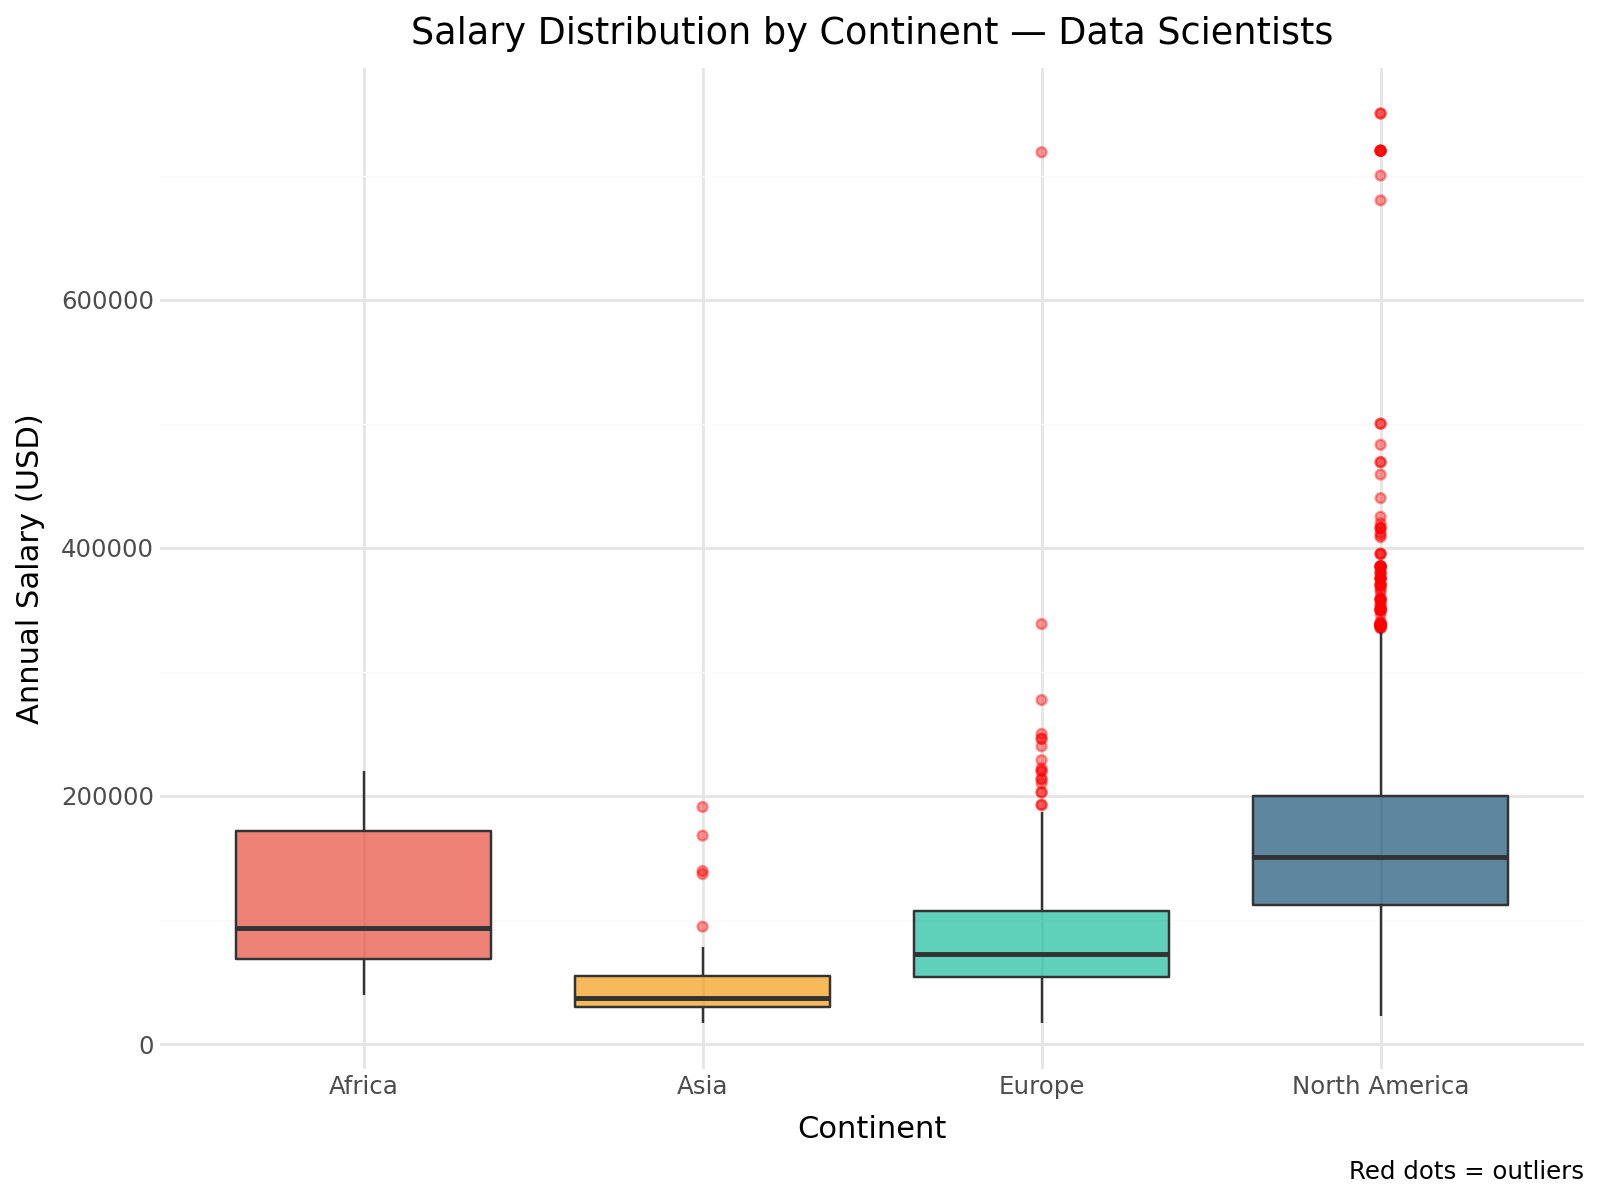

In [104]:
#   Salary variance and distribution comparison 
# Box plot — best for showing spread and outliers
(ggplot(ds2,
        aes(x='continent', y='salary_in_usd', fill='continent'))
+ geom_boxplot(alpha=0.7, outlier_color='red',
               outlier_alpha=0.4, outlier_size=1.5)
+ scale_fill_manual(values={
    'Africa'       : '#E74C3C',
    'Asia'         : '#F39C12',
    'North America': '#1A5276',
    'Europe'       : '#1ABC9C'
  })
+ labs(
    title   = 'Salary Distribution by Continent — Data Scientists',
    x       = 'Continent',
    y       = 'Annual Salary (USD)',
    caption = 'Red dots = outliers'
  )
+ theme_minimal()
+ theme(figure_size=(8, 6), legend_position='none')
)

## Does North America show a wider distribution of salaries compared to Africa or Asia? 

In [105]:
# Variance comparison table 
variance_table = (ds2
    .groupby('continent')['salary_in_usd']
    .agg(
        variance = 'var',
        std      = 'std',
        IQR      = lambda x: x.quantile(0.75) - x.quantile(0.25),
        range    = lambda x: x.max() - x.min()
    )
    .reset_index()
    .sort_values('std', ascending=False)
    .round(2))

print("=== Salary Spread By Region ===")
print(variance_table)

=== Salary Spread By Region ===
       continent      variance       std        IQR   range
3  North America  4.804411e+09  69313.86   88301.75  727700
0         Africa  4.246426e+09  65164.61  103343.00  180755
2         Europe  3.198420e+09  56554.58   53292.00  702084
1           Asia  1.793316e+09  42347.57   24813.50  174196


Plot saved successfully!


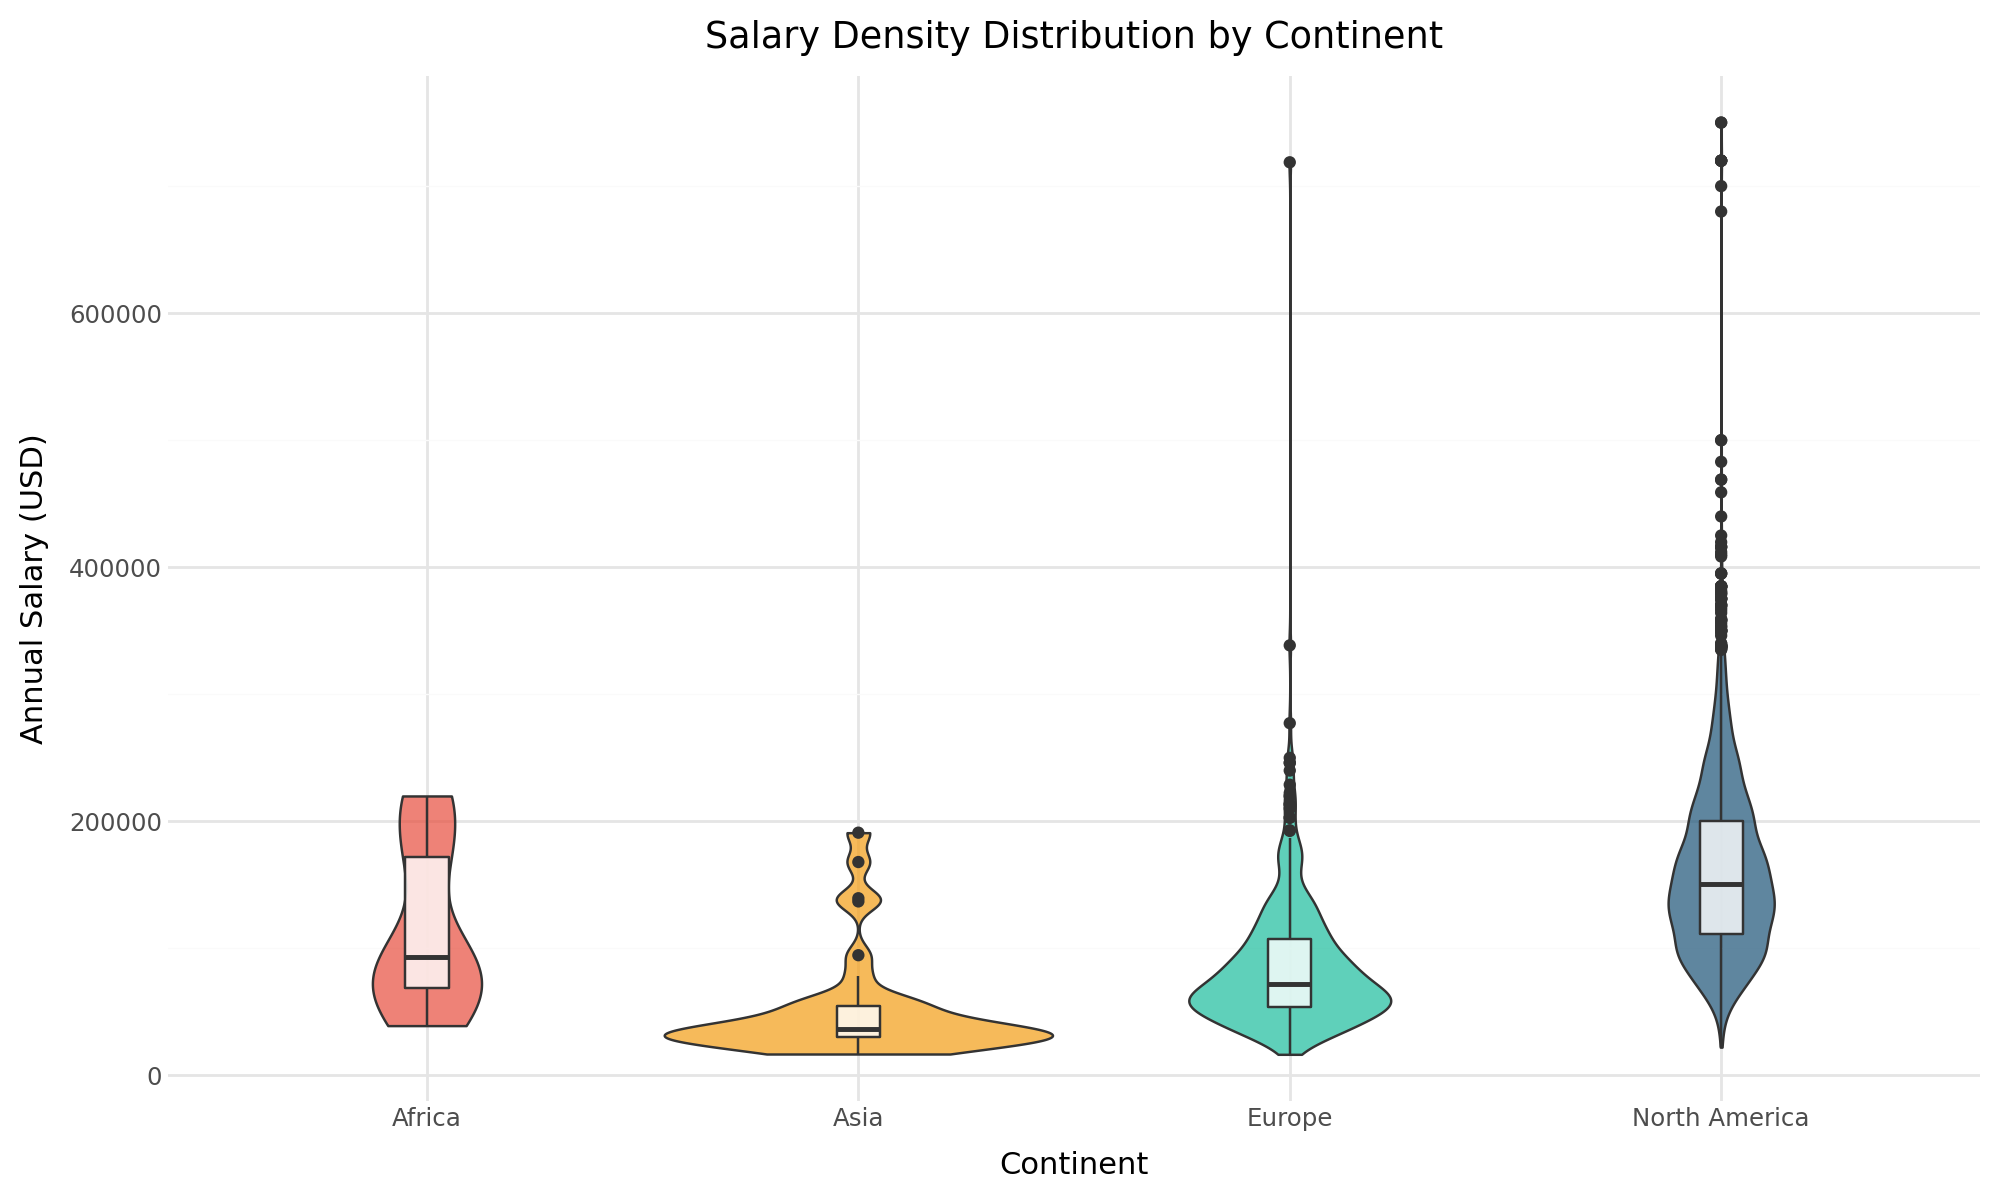

In [169]:
#  Violin plot shows distribution shape clearly but i decided to combine it with boxplot
q = (ggplot(ds2,
        aes(x='continent', y='salary_in_usd', fill='continent'))
+ geom_violin(alpha=0.7)
+ geom_boxplot(width=0.1, fill='white', alpha=0.8)
+ scale_fill_manual(values={
    'Africa'       : '#E74C3C',
    'Asia'         : '#F39C12',
    'North America': '#1A5276',
    'Europe'       : '#1ABC9C'
  })
+ labs(
    title='Salary Density Distribution by Continent',
    x='Continent',
    y='Annual Salary (USD)'
  )
+ theme_minimal()
+ theme(figure_size=(10, 6), legend_position='none')
)
q.save('salary_density_distr_continent.png',# save plot
       dpi    = 300,          # high resolution
       width  = 14,
       height = 8)

print("Plot saved successfully!")
q.show()


## Are there extreme outliers in specific regions that pull the global average away from the typical salary?

In [107]:
# Identify outliers per region 
# IQR is the interquartile range
def find_outliers(group):
    Q1  = group['salary_in_usd'].quantile(0.25)
    Q3  = group['salary_in_usd'].quantile(0.75)
    IQR = Q3 - Q1
    return group[group['salary_in_usd'] > Q3 + 1.5 * IQR]

# Select only the relevant columns first, then group
outliers = (ds2[['continent', 'salary_in_usd']]
            .groupby('continent', group_keys=False)
            .apply(find_outliers))
    
outlier_summary = (outliers
    .groupby('continent')['salary_in_usd']
    .agg(
        outlier_count = 'count',
        min_outlier   = 'min',
        max_outlier   = 'max',
        mean_outlier  = 'mean'
    )
    .reset_index()
    .round(2))

print("=== Outliers Per Region ===")
print(outlier_summary)

=== Outliers Per Region ===
       continent  outlier_count  min_outlier  max_outlier  mean_outlier
0           Asia              5        94665       191100     146053.00
1         Europe             18       192500       718750     257570.11
2  North America             83       335000       750000     414071.22


In [108]:
# Global mean vs median comparison 
global_mean   = ds2['salary_in_usd'].mean()
global_median = ds2['salary_in_usd'].median()

print(f"Global Mean Salary   : ${global_mean:,.0f}")
print(f"Global Median Salary : ${global_median:,.0f}")
print(f"Gap (Mean - Median)  : ${global_mean - global_median:,.0f}")
print("Positive gap = high earners pulling mean above typical salary")

Global Mean Salary   : $155,033
Global Median Salary : $145,000
Gap (Mean - Median)  : $10,033
Positive gap = high earners pulling mean above typical salary


# Experience and Role Demographics

## How does the distribution of experience levels (Entry, Mid, Senior, Executive) vary across the four continents?  

=== Experience Level Distribution By Region ===
        continent experience_level  count  total  percentage
0          Africa      Entry Level      3     20        15.0
1          Africa        Mid Level     11     20        55.0
2          Africa     Senior Level      6     20        30.0
3            Asia      Entry Level      6     36        16.7
4            Asia        Mid Level     16     36        44.4
5            Asia     Senior Level     14     36        38.9
6          Europe      Entry Level     63    411        15.3
7          Europe  Executive Level     14    411         3.4
8          Europe        Mid Level    182    411        44.3
9          Europe     Senior Level    152    411        37.0
10  North America      Entry Level    348   5218         6.7
11  North America  Executive Level    148   5218         2.8
12  North America        Mid Level   1711   5218        32.8
13  North America     Senior Level   3011   5218        57.7
Plot saved successfully!


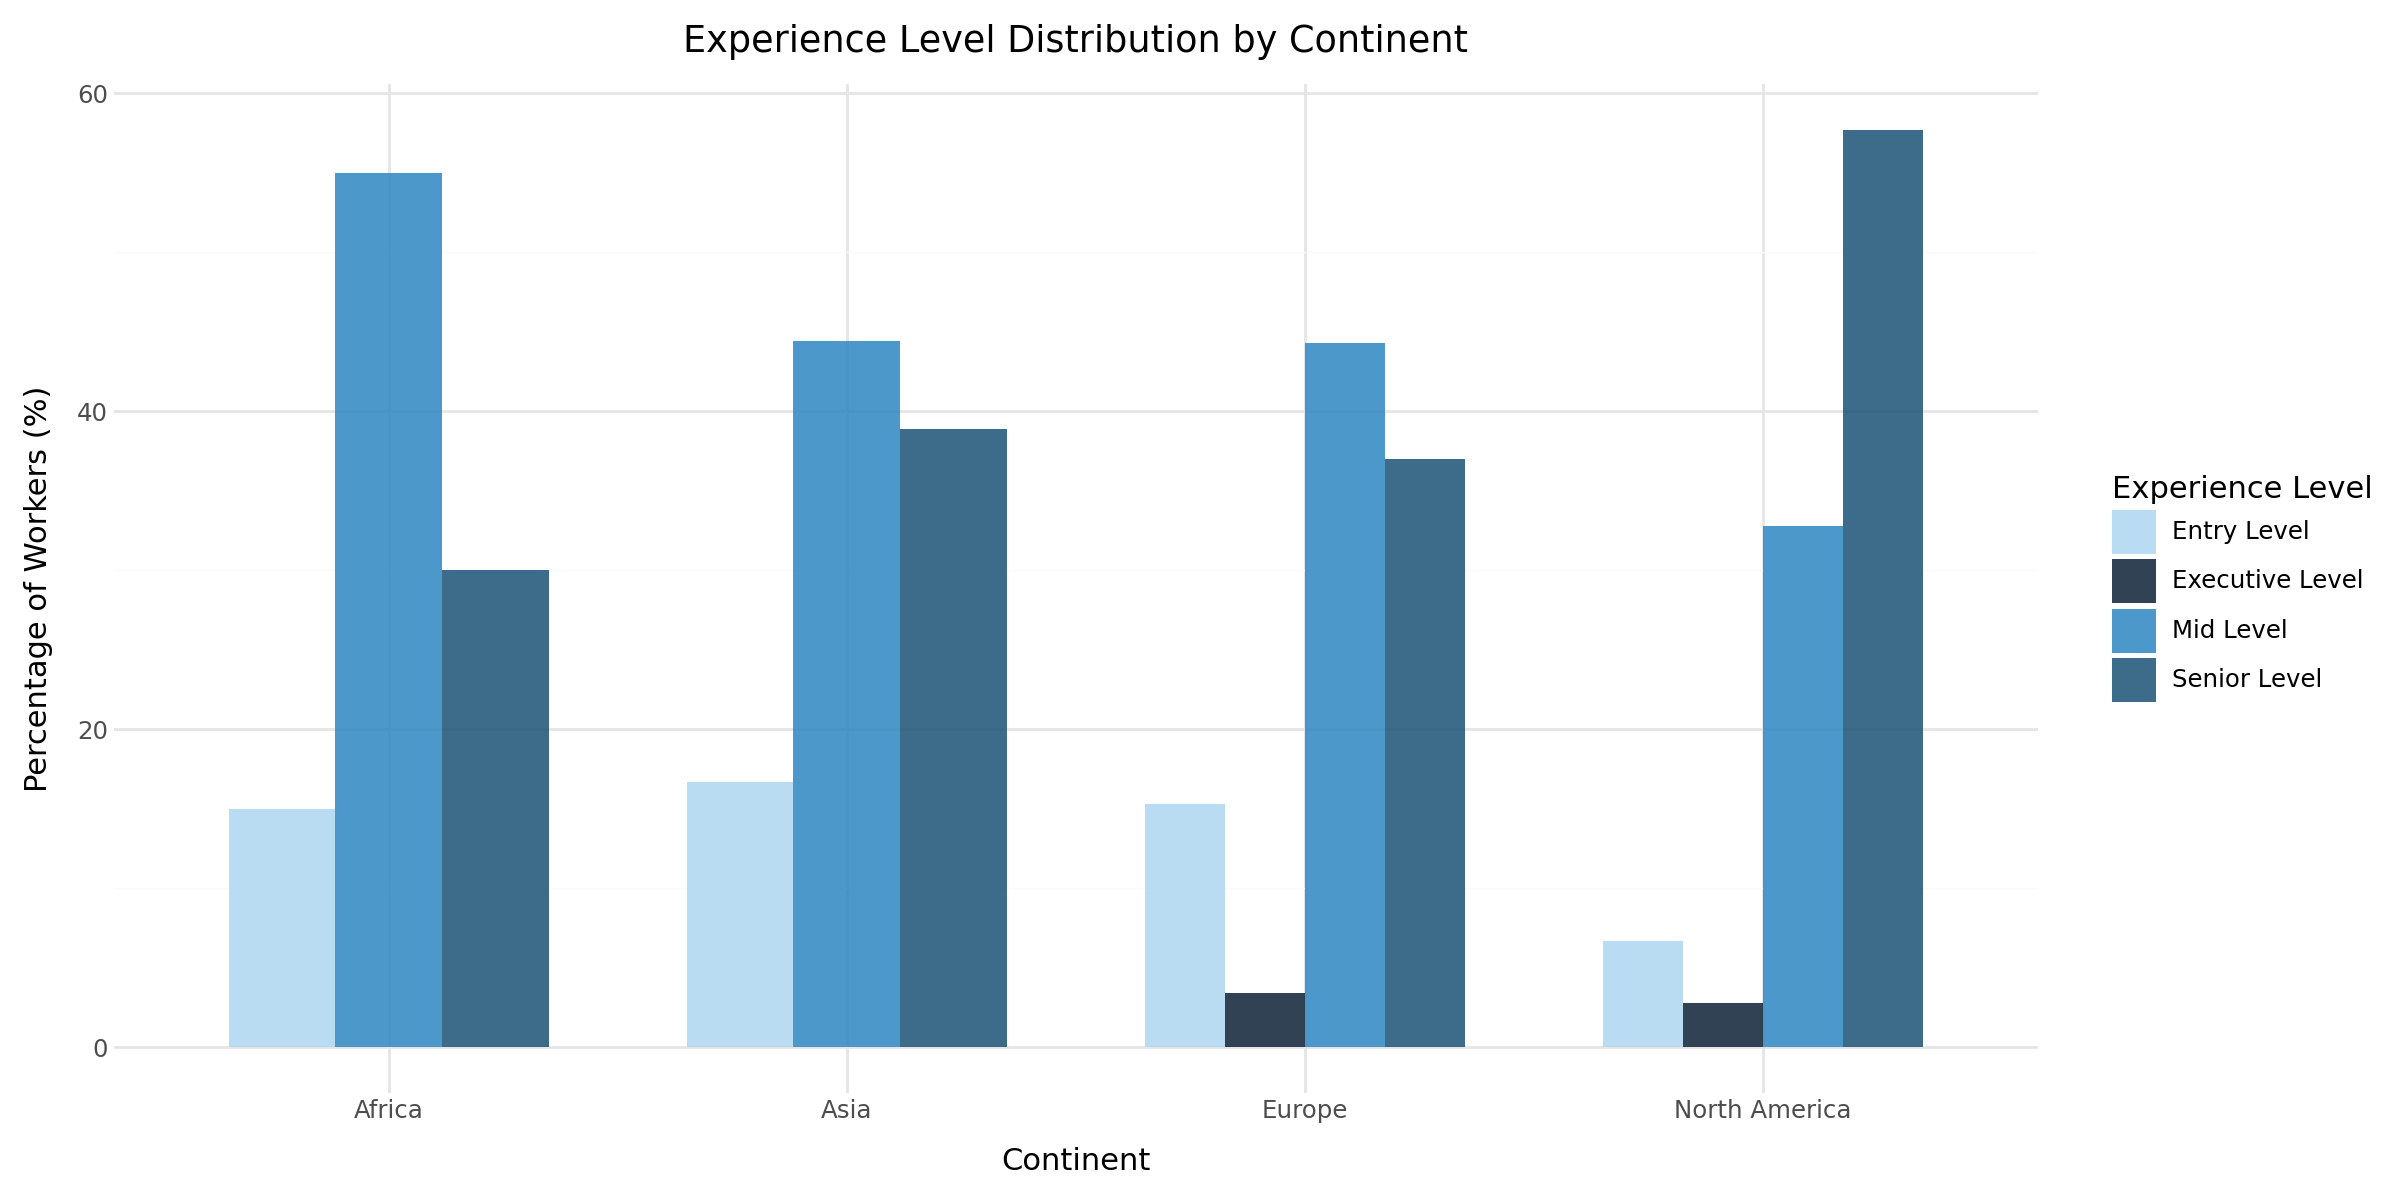

In [168]:
# Experience level distribution per continent 
exp_dist = (ds2
    .groupby(['continent', 'experience_level'])
    .size()
    .reset_index(name='count'))

exp_dist['total'] = exp_dist.groupby('continent')['count'].transform('sum')
exp_dist['percentage'] = (exp_dist['count'] / exp_dist['total'] * 100).round(1)

print("=== Experience Level Distribution By Region ===")
print(exp_dist)

# Visualise
g = (ggplot(exp_dist,
        aes(x='continent', y='percentage', fill='experience_level'))
+ geom_col(position='dodge', alpha=0.85, width=0.7)
+ scale_fill_manual(values={
    'Entry Level'    : '#AED6F1',
    'Mid Level'      : '#2E86C1',
    'Senior Level'   : '#1A5276',
    'Executive Level': '#0D2137'
  })
+ labs(
    title  = 'Experience Level Distribution by Continent',
    x      = 'Continent',
    y      = 'Percentage of Workers (%)',
    fill   = 'Experience Level'
  )
+ theme_minimal()
+ theme(figure_size=(12, 6))
)
g.save('experience_level_distr_continent.png',# save plot
       dpi    = 300,          # high resolution
       width  = 14,
       height = 8)

print("Plot saved successfully!")
g.show()


## Does a Senior Data Scientist in Asia or Africa out-earn an Entry-level Data Scientist in North America or Europe?  

In [110]:
# Does Senior Asia/Africa out-earn Entry NA/Europe? 
# Get median salary per experience level per region
exp_salary = (ds2
    .groupby(['continent', 'experience_level'])['salary_in_usd']
    .agg(
        median = 'median',
        mean   = 'mean',
        count  = 'count'
    )
    .reset_index()
    .round(2))

print("=== Salary By Experience Level and Region ===")
print(exp_salary.sort_values(['experience_level', 'median'],
                              ascending=[True, False]))

# Filter for the specific comparison
senior_asia   = exp_salary[(exp_salary['continent']=='Asia') &
                            (exp_salary['experience_level']=='Senior Level')]['median'].values[0]
senior_africa = exp_salary[(exp_salary['continent']=='Africa') &
                            (exp_salary['experience_level']=='Senior Level')]['median'].values[0]
entry_na      = exp_salary[(exp_salary['continent']=='North America') &
                            (exp_salary['experience_level']=='Entry Level')]['median'].values[0]
entry_europe  = exp_salary[(exp_salary['continent']=='Europe') &
                            (exp_salary['experience_level']=='Entry Level')]['median'].values[0]

print(f"\nSenior Asia median     : ${senior_asia:,.0f}")
print(f"Senior Africa median   : ${senior_africa:,.0f}")
print(f"Entry N.America median : ${entry_na:,.0f}")
print(f"Entry Europe median    : ${entry_europe:,.0f}")

# Answer the question
if senior_asia > entry_na:
    print("\n✅ Senior Asia out-earns Entry North America")
else:
    print("\n❌ Entry North America out-earns Senior Asia")

=== Salary By Experience Level and Region ===
        continent experience_level    median       mean  count
10  North America      Entry Level  100000.0  109382.40    348
0          Africa      Entry Level   96600.0  122200.00      3
6          Europe      Entry Level   49646.0   53866.48     63
3            Asia      Entry Level   29075.0   29807.83      6
11  North America  Executive Level  200000.0  207178.49    148
7          Europe  Executive Level  143193.0  158921.00     14
12  North America        Mid Level  131000.0  142355.62   1711
1          Africa        Mid Level   75600.0   96275.45     11
8          Europe        Mid Level   67697.5   79623.92    182
4            Asia        Mid Level   34404.0   48135.19     16
13  North America     Senior Level  166080.0  175711.14   3011
2          Africa     Senior Level  134300.0  144916.67      6
9          Europe     Senior Level   91140.0  103419.76    152
5            Asia     Senior Level   45899.0   66191.57     14

Senior A

## Does a Senior Data Scientist in Europe out-earn a Senior Data Scientist in North America?

In [111]:
senior_europe  = exp_salary[(exp_salary['continent']=='Europe') &
                            (exp_salary['experience_level']=='Senior Level')]['median'].values[0]
senior_na = exp_salary[(exp_salary['continent']=='North America') &
                            (exp_salary['experience_level']=='Senior Level')]['median'].values[0]

print(f"\nSenior Europe median     : ${senior_europe:,.0f}")
print(f"Senior N.America median   : ${senior_na:,.0f}")

# Answer the question
if senior_europe > senior_na:
    print("\n✅ Senior Europe out-earns Senior North America")
else:
    print("\n❌ Senior North America out-earns Senior Europe")



Senior Europe median     : $91,140
Senior N.America median   : $166,080

❌ Senior North America out-earns Senior Europe


## Median salary by experience level and continent

Plot saved successfully!


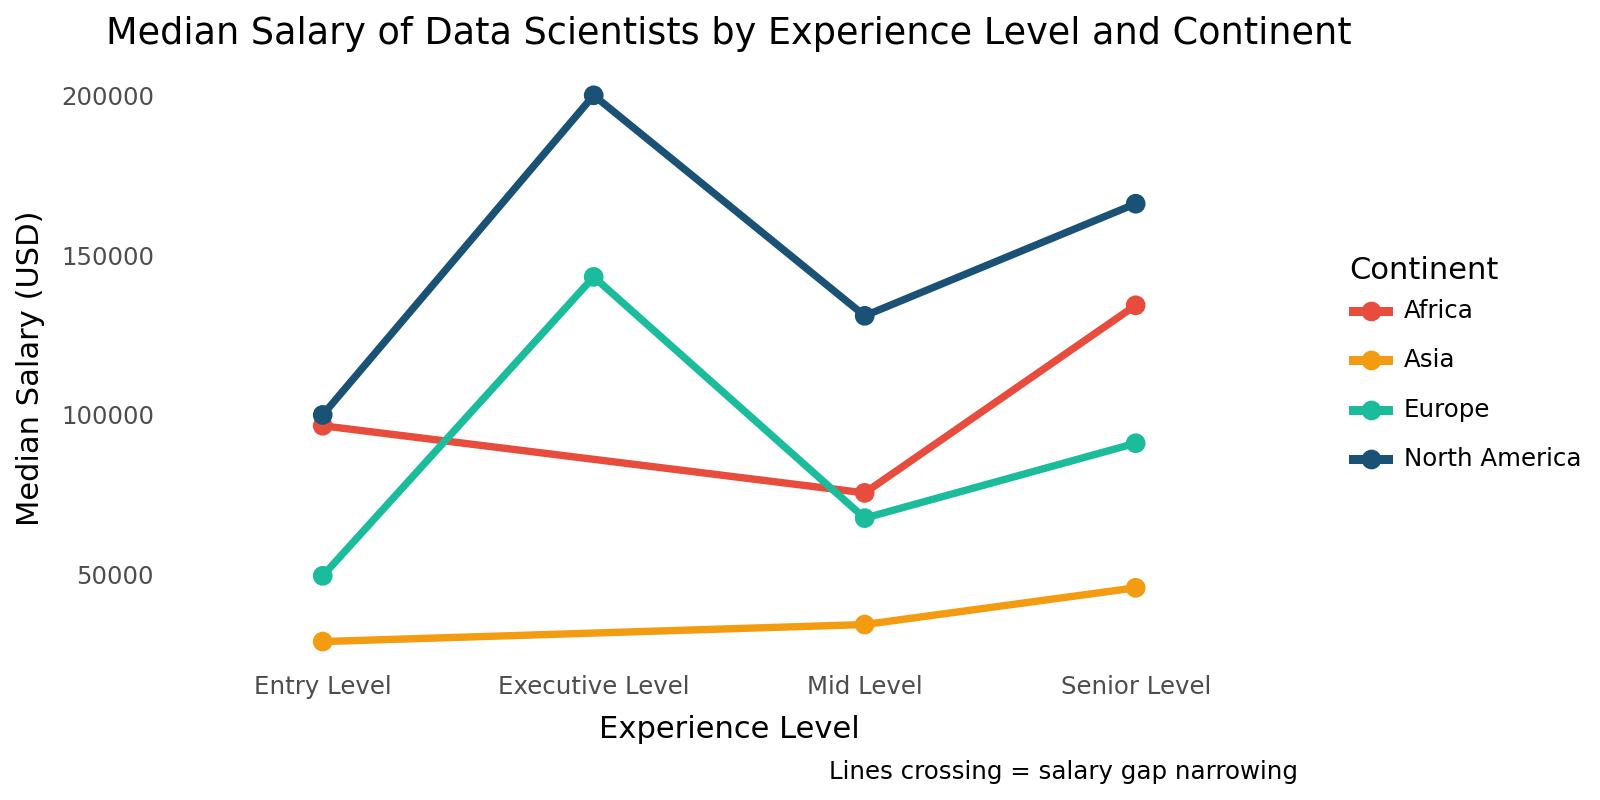

In [167]:
# Visualise salary by experience across regions 
l = (ggplot(exp_salary,
        aes(x='experience_level', y='median',
            color='continent', group='continent'))
+ geom_line(size=1.5)
+ geom_point(size=3)
+ scale_color_manual(values={
    'Africa'       : '#E74C3C',
    'Asia'         : '#F39C12',
    'North America': '#1A5276',
    'Europe'       : '#1ABC9C'
  })
+ labs(
    title  = 'Median Salary of Data Scientists by Experience Level and Continent',
    x      = 'Experience Level',
    y      = 'Median Salary (USD)',
    color  = 'Continent',
    caption= 'Lines crossing = salary gap narrowing'
  )
+ theme_minimal()
+ theme(
    figure_size=(8, 4),
    panel_grid_major = element_blank(),
    panel_grid_minor = element_blank()
    )
)
l.save('Median_salary_by_experience_level_continent.png',# save plot
       dpi    = 300,          # high resolution
       width  = 14,
       height = 8)

print("Plot saved successfully!")
l.show()


## At which specific experience tier does the salary gap between continents narrow or widen the most?

In [113]:
# Where does the gap widen or narrow the most? 
# Calculate salary gap between North America and each region
pivot = exp_salary.pivot_table(
    index  = 'experience_level',
    columns= 'continent',
    values = 'median'
).reset_index()

pivot['gap_na_africa'] = pivot['North America'] - pivot['Africa']
pivot['gap_na_asia']   = pivot['North America'] - pivot['Asia']
pivot['gap_na_europe'] = pivot['North America'] - pivot['Europe']

print("=== Salary Gap vs North America By Experience Level ===")
print(pivot[['experience_level', 'gap_na_africa',
             'gap_na_asia', 'gap_na_europe']].round(0))

# Find where gap is largest and smallest
for col, region in [('gap_na_africa', 'Africa'),
                    ('gap_na_asia', 'Asia'),
                    ('gap_na_europe', 'Europe')]:
    max_gap = pivot.loc[pivot[col].idxmax(), 'experience_level']
    min_gap = pivot.loc[pivot[col].idxmin(), 'experience_level']
    print(f"\nNA vs {region}:")
    print(f"  Widest gap at  : {max_gap}")
    print(f"  Narrowest gap at: {min_gap}")

=== Salary Gap vs North America By Experience Level ===
continent experience_level  gap_na_africa  gap_na_asia  gap_na_europe
0              Entry Level         3400.0      70925.0        50354.0
1          Executive Level            NaN          NaN        56807.0
2                Mid Level        55400.0      96596.0        63302.0
3             Senior Level        31780.0     120181.0        74940.0

NA vs Africa:
  Widest gap at  : Mid Level
  Narrowest gap at: Entry Level

NA vs Asia:
  Widest gap at  : Senior Level
  Narrowest gap at: Entry Level

NA vs Europe:
  Widest gap at  : Senior Level
  Narrowest gap at: Entry Level


# Employment Structure & Macro Factors

## What proportion of data scientists in Africa and Asia are working remotely for foreign companies vs. local companies? 

In [114]:
# Create work arrangement column
ds2['work_arrangement'] = np.where(
    ds2['employee_residence'] == ds2['company_location'],
    'Local Company',
    'Foreign Company'
)

# Filter for Africa and Asia only 
africa_asia = ds2[
    ds2['continent'].isin(['Africa', 'Asia'])
]

print(f"Africa & Asia total records: {len(africa_asia):,}")
print(africa_asia['continent'].value_counts())

Africa & Asia total records: 56
continent
Asia      36
Africa    20
Name: count, dtype: int64


In [115]:
#  Count and proportion 
proportion = (africa_asia
    .groupby(['continent', 'work_arrangement'])
    .size()
    .reset_index(name='count'))

proportion['total'] = proportion.groupby(
    'continent')['count'].transform('sum')

proportion['percentage'] = (
    proportion['count'] / proportion['total'] * 100
).round(1)

print("\n=== Work Arrangement Proportion — Africa & Asia ===")
print(proportion)


=== Work Arrangement Proportion — Africa & Asia ===
  continent work_arrangement  count  total  percentage
0    Africa    Local Company     20     20       100.0
1      Asia  Foreign Company      3     36         8.3
2      Asia    Local Company     33     36        91.7


In [116]:
# Specifically remote workers 
remote_breakdown = (africa_asia
    .groupby(['continent', 'work_arrangement', 'remote_ratio'])
    .size()
    .reset_index(name='count'))

# Map remote ratio to labels
remote_breakdown['remote_type'] = remote_breakdown['remote_ratio'].map({
    0   : 'On-site',
    50  : 'Hybrid',
    100 : 'Fully Remote'
})

# Total per region
remote_breakdown['total'] = remote_breakdown.groupby(
    'continent')['count'].transform('sum')
remote_breakdown['percentage'] = (
    remote_breakdown['count'] / remote_breakdown['total'] * 100
).round(1)

print("\n=== Remote Breakdown By Arrangement — Africa & Asia ===")
print(remote_breakdown[[
    'continent', 'work_arrangement',
    'remote_type', 'count', 'percentage'
]])


=== Remote Breakdown By Arrangement — Africa & Asia ===
  continent work_arrangement   remote_type  count  percentage
0    Africa    Local Company       On-site     17        85.0
1    Africa    Local Company        Hybrid      1         5.0
2    Africa    Local Company  Fully Remote      2        10.0
3      Asia  Foreign Company  Fully Remote      3         8.3
4      Asia    Local Company       On-site      7        19.4
5      Asia    Local Company        Hybrid      9        25.0
6      Asia    Local Company  Fully Remote     17        47.2


In [117]:
#  Key Comparison Table 
# Fully Remote + Foreign Company specifically
remote_foreign = (africa_asia
    .groupby('continent')
    .apply(lambda x: pd.Series({
        'Total Workers'              : len(x),
        'Foreign Company'            : (x['work_arrangement'] == 'Foreign Company').sum(),
        'Local Company'              : (x['work_arrangement'] == 'Local Company').sum(),
        'Remote + Foreign'           : ((x['remote_ratio'] == 100) & (x['work_arrangement'] == 'Foreign Company')).sum(),
        'Remote + Local'             : ((x['remote_ratio'] == 100) & (x['work_arrangement'] == 'Local Company')).sum(),
        'Onsite + Foreign'           : ((x['remote_ratio'] == 0) & (x['work_arrangement'] == 'Foreign Company')).sum(),
        'Onsite + Local'             : ((x['remote_ratio'] == 0) & (x['work_arrangement'] == 'Local Company')).sum(),
    }))
    .reset_index())

# Add percentages
remote_foreign['% Foreign']         = (remote_foreign['Foreign Company'] / remote_foreign['Total Workers'] * 100).round(1)
remote_foreign['% Local']           = (remote_foreign['Local Company']   / remote_foreign['Total Workers'] * 100).round(1)
remote_foreign['% Remote + Foreign']= (remote_foreign['Remote + Foreign']/ remote_foreign['Total Workers'] * 100).round(1)

print("\n=== Complete Breakdown ===")
print(remote_foreign.to_string(index=False))


=== Complete Breakdown ===
continent  Total Workers  Foreign Company  Local Company  Remote + Foreign  Remote + Local  Onsite + Foreign  Onsite + Local  % Foreign  % Local  % Remote + Foreign
   Africa             20                0             20                 0               2                 0              17        0.0    100.0                 0.0
     Asia             36                3             33                 3              17                 0               7        8.3     91.7                 8.3


Plot saved successfully!


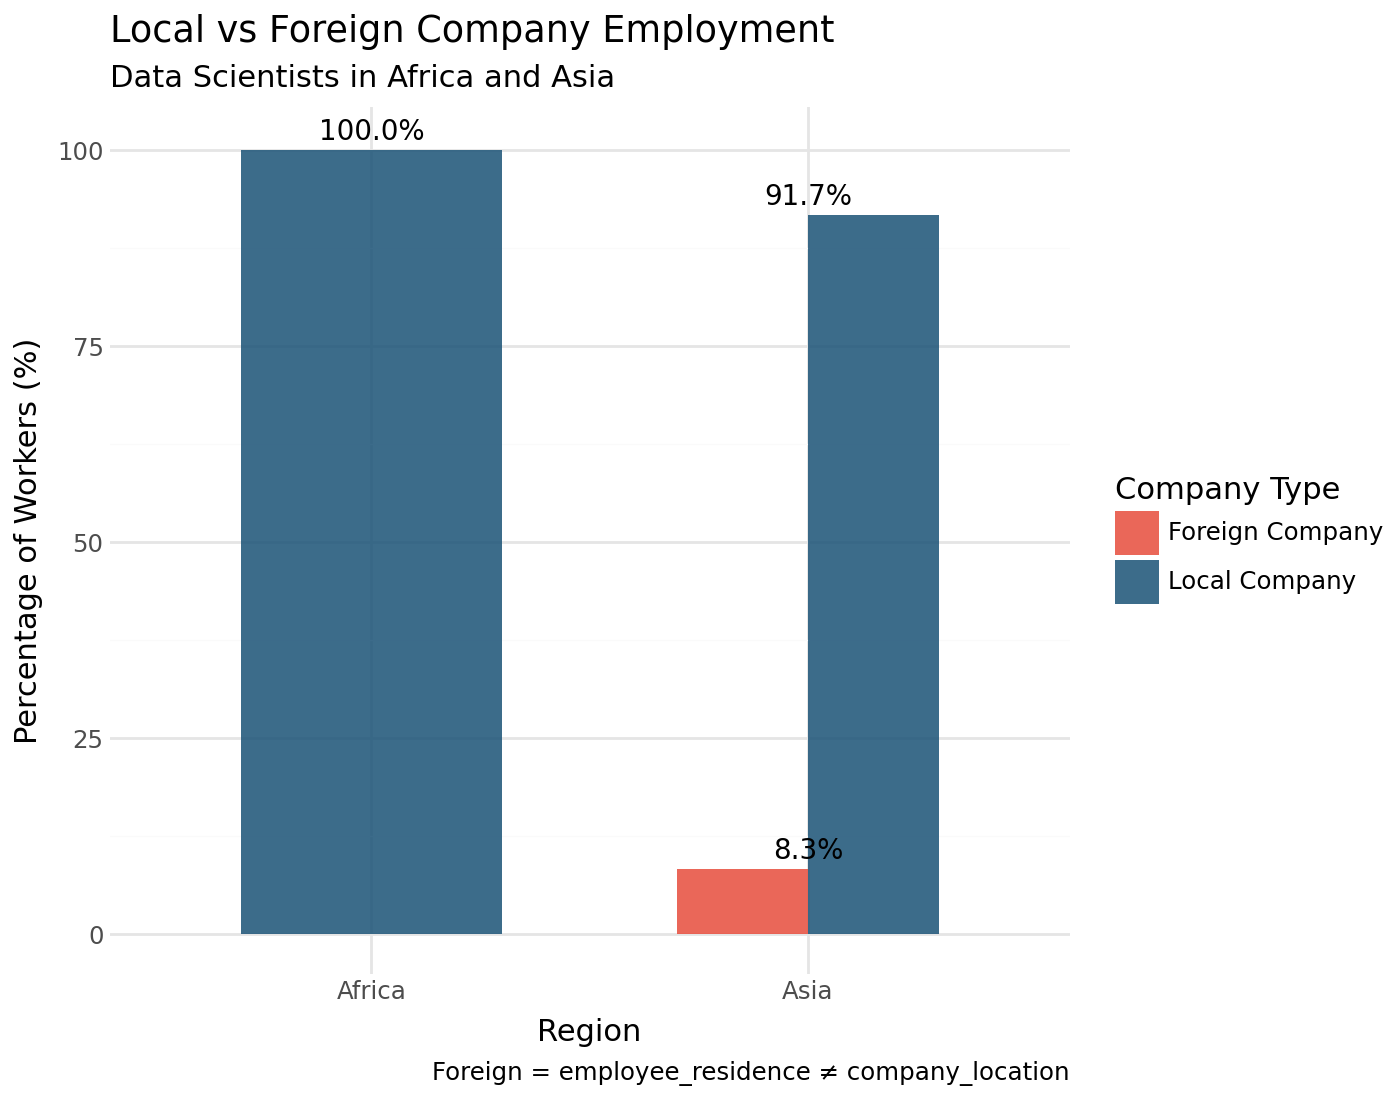

In [166]:
# Visualise Foreign vs Local 
from plotnine import *

f = (ggplot(proportion,
        aes(x='continent', y='percentage', fill='work_arrangement'))
+ geom_col(position='dodge', alpha=0.85, width=0.6)
+ geom_text(aes(label='percentage.astype(str) + "%"'),
            position=position_dodge(width=0.6),
            va='bottom', size=10, nudge_y=0.5)
+ scale_fill_manual(values={
    'Local Company'  : '#1A5276',
    'Foreign Company': '#E74C3C'
  })
+ labs(
    title    = 'Local vs Foreign Company Employment',
    subtitle = 'Data Scientists in Africa and Asia',
    x        = 'Region',
    y        = 'Percentage of Workers (%)',
    fill     = 'Company Type',
    caption  = 'Foreign = employee_residence ≠ company_location'
  )
+ theme_minimal()
+ theme(figure_size=(7, 5.5))
)
f.save('Local_versus_foreign_company_employment.png',# save plot
       dpi    = 300,          # high resolution
       width  = 14,
       height = 8)

print("Plot saved successfully!")
f.show()


Plot saved successfully!


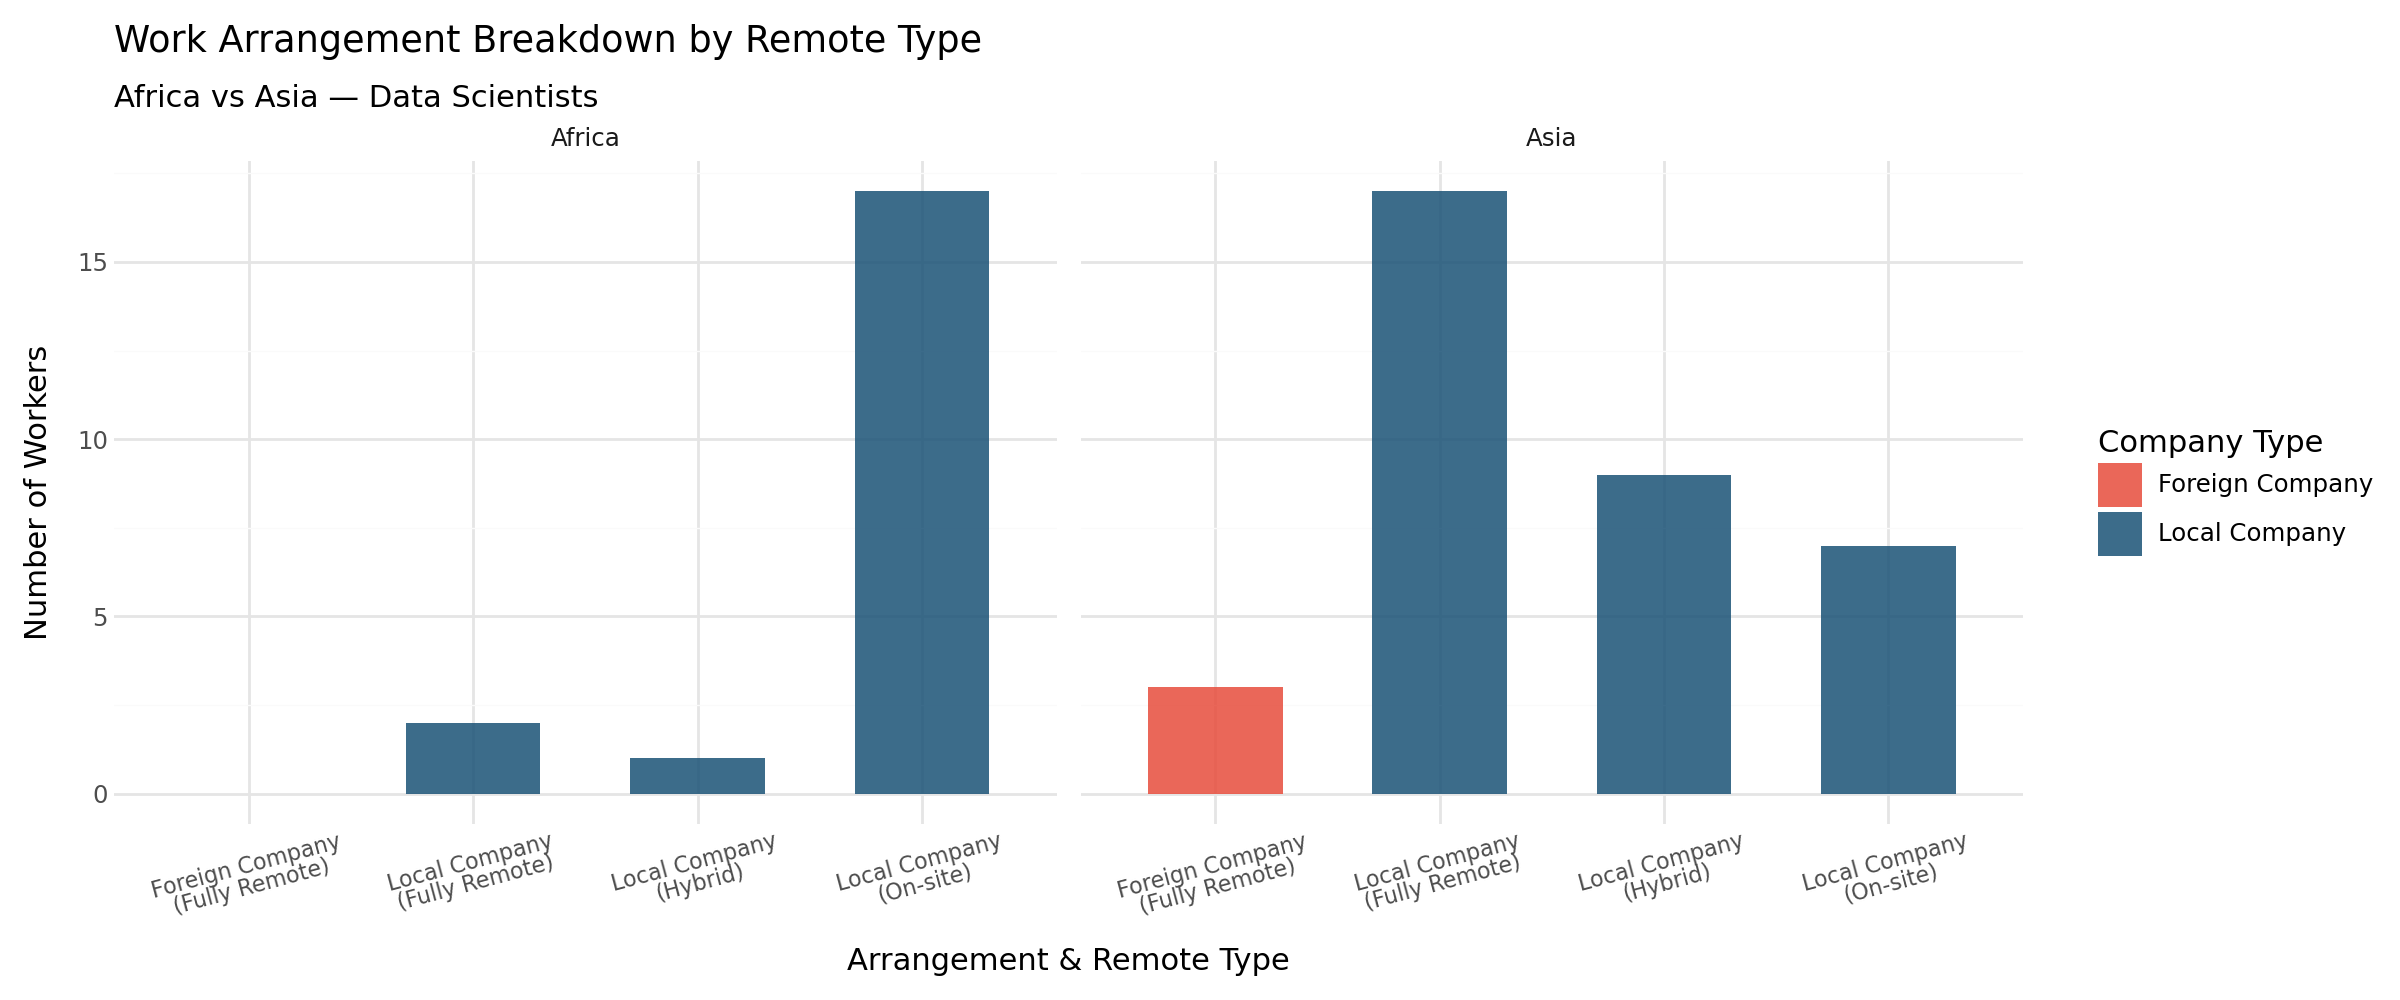

In [170]:
# ── Step 7 — Visualisation 2: Remote type breakdown ──────────
remote_viz = (africa_asia
    .groupby(['continent', 'work_arrangement', 'remote_ratio'])
    .size()
    .reset_index(name='count'))

remote_viz['remote_type'] = remote_viz['remote_ratio'].map({
    0: 'On-site', 50: 'Hybrid', 100: 'Fully Remote'
})

remote_viz['label'] = remote_viz['work_arrangement'] + '\n(' + remote_viz['remote_type'] + ')'

j = (ggplot(remote_viz,
        aes(x='label', y='count', fill='work_arrangement'))
+ geom_col(alpha=0.85, width=0.6)
+ facet_wrap('~continent')
+ scale_fill_manual(values={
    'Local Company'  : '#1A5276',
    'Foreign Company': '#E74C3C'
  })
+ labs(
    title    = 'Work Arrangement Breakdown by Remote Type',
    subtitle = 'Africa vs Asia — Data Scientists',
    x        = 'Arrangement & Remote Type',
    y        = 'Number of Workers',
    fill     = 'Company Type'
  )
+ theme_minimal()
+ theme(
    figure_size      = (12, 5),
    axis_text_x      = element_text(size=8, rotation=15),
    legend_position  = 'right'
  )
)
j.save('work_arrangement_breakdown_Africa_Asia.png',# save plot
       dpi    = 300,          # high resolution
       width  = 14,
       height = 8)

print("Plot saved successfully!")
j.show()

In [120]:
#  Salary comparison by arrangement 
salary_arrangement = (africa_asia
    .groupby(['continent', 'work_arrangement'])['salary_in_usd']
    .agg(
        median = 'median',
        mean   = 'mean',
        count  = 'count'
    )
    .reset_index()
    .round(2))

print("\n=== Salary By Work Arrangement ===")
print(salary_arrangement)

# Calculate foreign company premium
for region in ['Africa', 'Asia']:
    reg = salary_arrangement[salary_arrangement['continent'] == region]
    if len(reg) == 2:
        foreign = reg[reg['work_arrangement'] == 'Foreign Company']['median'].values
        local   = reg[reg['work_arrangement'] == 'Local Company']['median'].values
        if len(foreign) > 0 and len(local) > 0:
            premium = foreign[0] - local[0]
            pct     = (premium / local[0] * 100)
            print(f"\n{region} — Foreign Company Premium:")
            print(f"  Foreign median : ${foreign[0]:,.0f}")
            print(f"  Local median   : ${local[0]:,.0f}")
            print(f"  Premium        : ${premium:,.0f} ({pct:.1f}% more)")


=== Salary By Work Arrangement ===
  continent work_arrangement   median       mean  count
0    Africa    Local Company  93300.0  114756.50     20
1      Asia  Foreign Company  40000.0   44472.00      3
2      Asia    Local Company  33808.0   52796.24     33

Asia — Foreign Company Premium:
  Foreign median : $40,000
  Local median   : $33,808
  Premium        : $6,192 (18.3% more)


## How do the salaries of remote workers in these regions compare to those working for local firms? 

In [121]:
# OR lets answer the previous question this way
# Salary comparison — remote foreign vs local workers 
salary_by_arrangement = (africa_asia
    .groupby(['continent', 'work_arrangement'])['salary_in_usd']
    .agg(
        mean   = 'mean',
        median = 'median',
        count  = 'count'
    )
    .reset_index()
    .round(2))

print("=== Salary By Work Arrangement — Africa & Asia ===")
print(salary_by_arrangement)

# Calculate the pay gap
pivot_salary = salary_by_arrangement.pivot(
    index='continent', columns='work_arrangement', values='median'
).reset_index()
pivot_salary['foreign_premium'] = (
    pivot_salary['Foreign Company'] - pivot_salary['Local Company']
)
pivot_salary['foreign_premium_pct'] = (
    pivot_salary['foreign_premium'] / pivot_salary['Local Company'] * 100
).round(1)

print("\n=== Foreign Company Salary Premium ===")
print(pivot_salary)

=== Salary By Work Arrangement — Africa & Asia ===
  continent work_arrangement       mean   median  count
0    Africa    Local Company  114756.50  93300.0     20
1      Asia  Foreign Company   44472.00  40000.0      3
2      Asia    Local Company   52796.24  33808.0     33

=== Foreign Company Salary Premium ===
work_arrangement continent  Foreign Company  Local Company  foreign_premium  \
0                   Africa              NaN        93300.0              NaN   
1                     Asia          40000.0        33808.0           6192.0   

work_arrangement  foreign_premium_pct  
0                                 NaN  
1                                18.3  


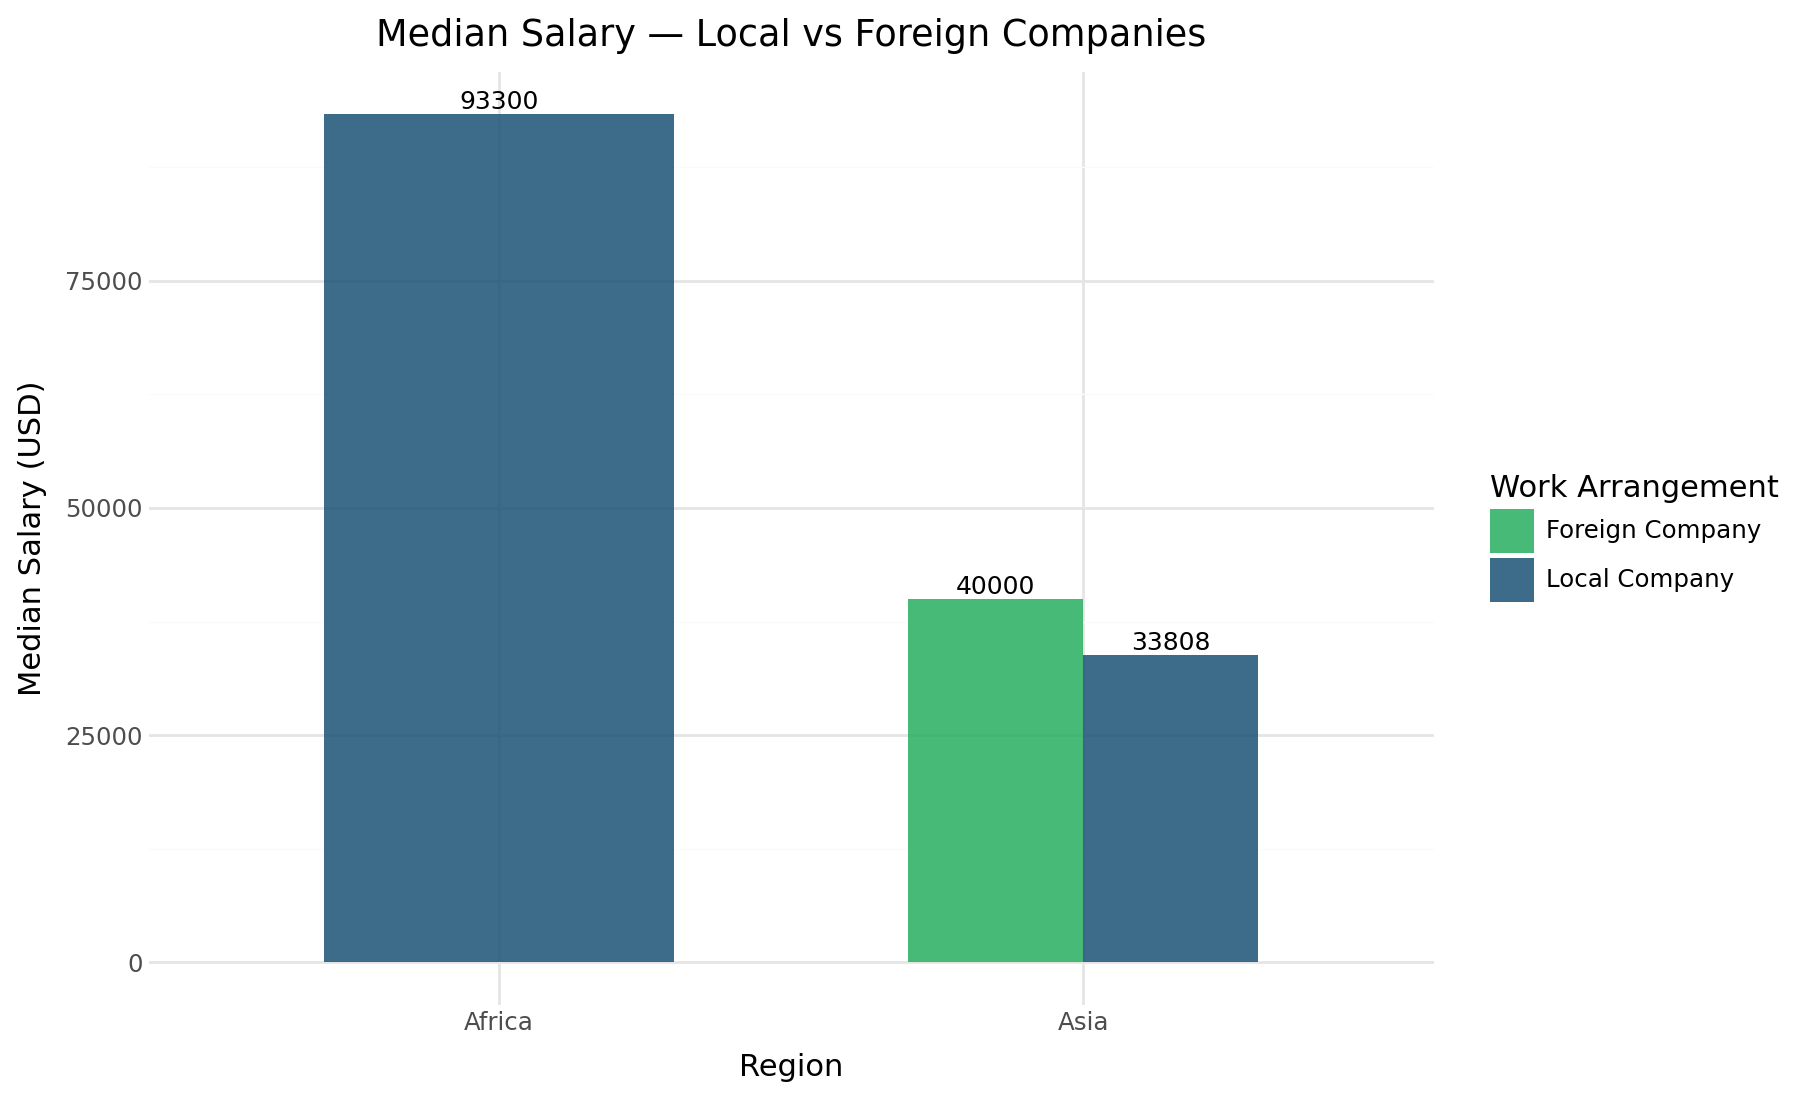

In [122]:
#  Visualise the pay gap 
(ggplot(salary_by_arrangement,
        aes(x='continent', y='median', fill='work_arrangement'))
+ geom_col(position='dodge', alpha=0.85, width=0.6)
+ geom_text(aes(label='median.round().astype(int)'),
            position=position_dodge(width=0.6), va='bottom', size=9)
+ scale_fill_manual(values={
    'Local Company'  : '#1A5276',
    'Foreign Company': '#27AE60'
  })
+ labs(
    title = 'Median Salary — Local vs Foreign Companies',
    x     = 'Region',
    y     = 'Median Salary (USD)',
    fill  = 'Work Arrangement'
  )
+ theme_minimal()
+ theme(figure_size=(9, 5.5))
)

## How does company size (Small Startup vs. Enterprise) correlate with average salaries across these different regions?

In [123]:
# Aggregate salaries by continent and company size
company_size_impact = (ds2.groupby(['continent', 'company_size'])['salary_in_usd']
                       .agg(average_salary='mean',median_salary = 'median', employee_count='count')
                       .reset_index()
                       .round(2))

print("=== Company Size vs. Regional Salary ===")
print(company_size_impact)

=== Company Size vs. Regional Salary ===
        continent company_size  average_salary  median_salary  employee_count
0          Africa        Large        50000.00        50000.0               1
1          Africa       Medium       120285.00        94950.0              18
2          Africa        Small        80000.00        80000.0               1
3            Asia        Large        44837.94        40525.5              18
4            Asia       Medium        55231.56        31200.0              16
5            Asia        Small        92452.00        92452.0               2
6          Europe        Large        72508.19        64781.0              37
7          Europe       Medium        90319.23        75300.0             356
8          Europe        Small        55188.28        57786.0              18
9   North America        Large       150987.21       143100.0             168
10  North America       Medium       161684.22       151747.5            5032
11  North America      

Plot saved successfully!


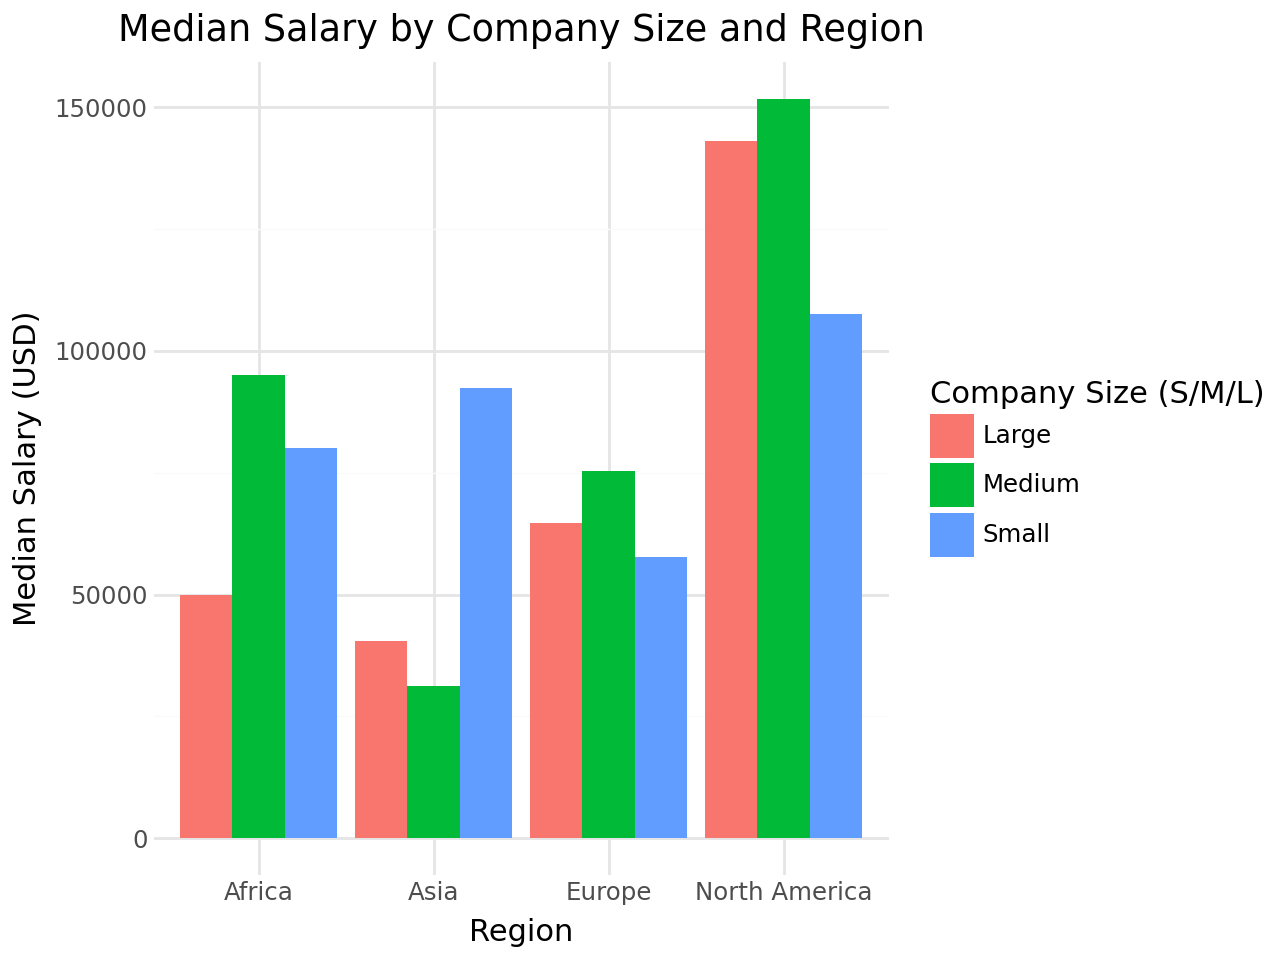

In [165]:
from plotnine import *

# Plot average salary by region and company size
e = (ggplot(ds2, aes(x='continent', y='salary_in_usd', fill='company_size'))
    + stat_summary(fun_y=np.median, geom='bar', position='dodge')
    + labs(
        title="Median Salary by Company Size and Region",
        x="Region",
        y="Median Salary (USD)",
        fill="Company Size (S/M/L)"
    )
    + theme_minimal()
)
e.save('Median_salary_company_size_region.png',# save plot
       dpi    = 300,          # high resolution
       width  = 14,
       height = 8)

print("Plot saved successfully!")
e.show()


In [125]:
# Correlation strength — company size vs salary 
# Encode company size ordinally for correlation
size_map = {'Small': 1, 'Medium': 2, 'Large': 3}
ds2['company_size_ordinal'] = ds2['company_size'].map(size_map)

for continent in ['Africa', 'Asia', 'North America', 'Europe']:
    region_data = ds2[ds2['continent'] == continent]
    corr = region_data['company_size_ordinal'].corr(region_data['salary_in_usd'])
    print(f"{continent}: Company Size vs Salary correlation = {corr:.3f}")

Africa: Company Size vs Salary correlation = -0.075
Asia: Company Size vs Salary correlation = -0.235
North America: Company Size vs Salary correlation = -0.018
Europe: Company Size vs Salary correlation = 0.004


## Do local cost-of-living indicators or currency payout types explain the variance in the baseline USD-equivalent salary?

Since the dataset does not contain an explicit "Cost of Living Index" column, employee_residence serves as a proxy indicator for cost of living, while salary_currency represents the payout type.

let us verify if paying in a global currency like USD or EUR removes the local geographic discount by running an aggregation

In [126]:
# See if the currency choice shifts the baseline USD salary within regions
variance_explainer = (ds2.groupby(['continent', 'salary_currency'])['salary_in_usd']
                      .agg(['count', 'min', 'max', 'median', 'std'])
                      .reset_index()
                      .round(2))

print("=== Currency Payout Impact on USD Baselines ===")
print(variance_explainer)

=== Currency Payout Impact on USD Baselines ===
        continent salary_currency  count    min     max    median       std
0          Africa             GBP      3  39245   55328   42457.0   8511.19
1          Africa             USD     17  50000  220000   96600.0  63094.56
2            Asia             INR     20  16904   94665   39698.0  20719.63
3            Asia             THB      2  24613   29301   26957.0   3314.92
4            Asia             USD     14  30000  191100   37500.0  59490.69
5          Europe             EUR    158  16666  338526   63000.0  36080.63
6          Europe             GBP    202  27885  718750   75474.5  59153.67
7          Europe             NOK      2  76508  100416   88462.0  16905.51
8          Europe             USD     49  30000  277300  144540.0  57663.48
9   North America             CAD     35  46428  197254   92307.0  41831.62
10  North America             EUR      7  25263  105555   68428.0  29458.98
11  North America             GBP      6

#### If the standard deviation (std) drops significantly or medians scale heavily upward whenever salary_currency == 'USD' (even in lower cost-of-living regions)
#### it proves that currency payout type is a primary driver of baseline salary variance, overriding local cost-of-living constraints.

Plot saved successfully!


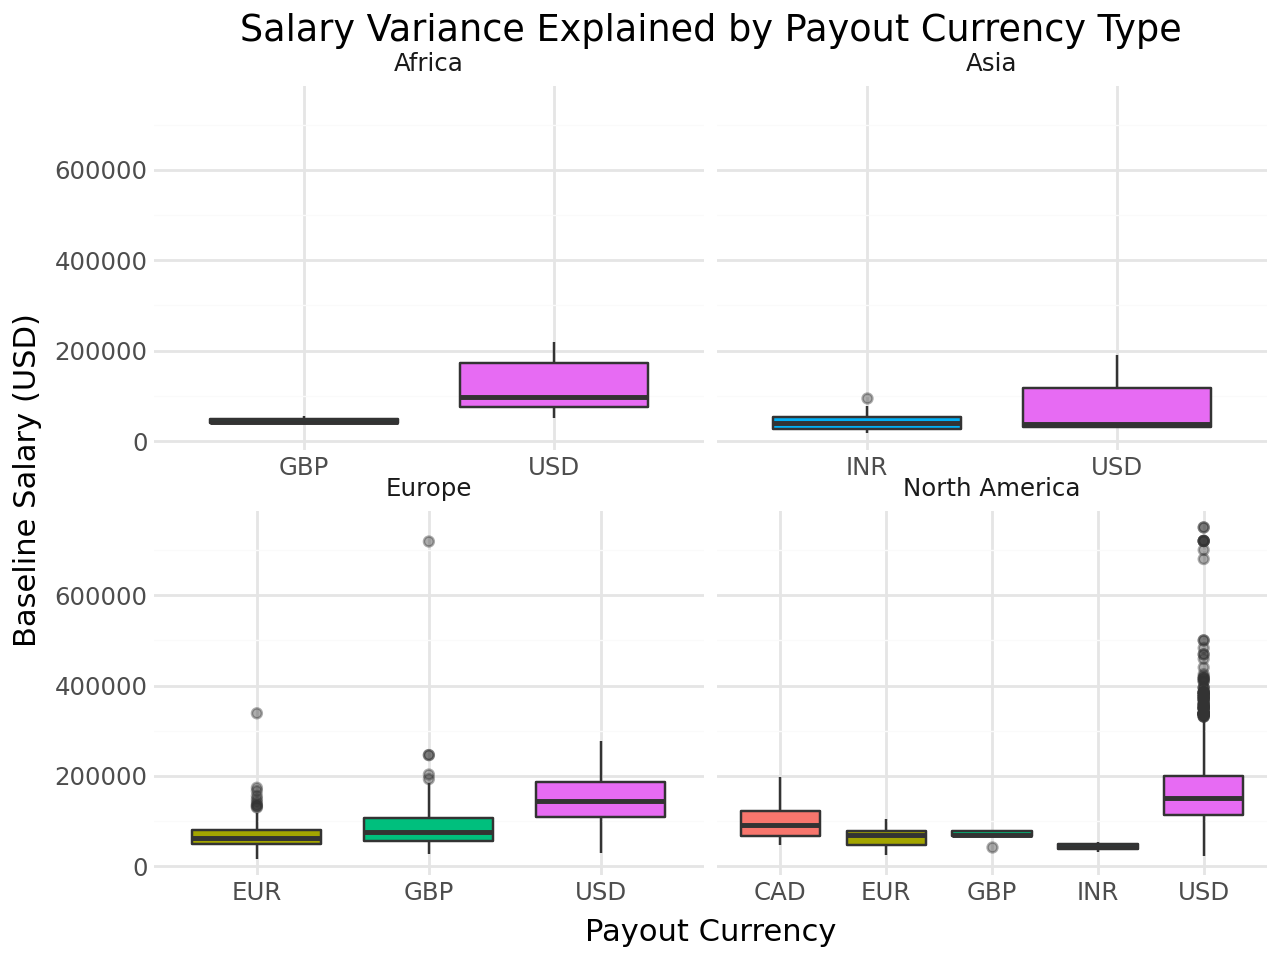

In [164]:
# Focus on the top currencies to avoid cluttering the plot
top_currencies = ds2['salary_currency'].value_counts().nlargest(5).index
filtered_currency_df = ds2[ds2['salary_currency'].isin(top_currencies)]

d =(ggplot(filtered_currency_df, aes(x='salary_currency', y='salary_in_usd', fill='salary_currency'))
    + geom_boxplot(outlier_alpha=0.4)
    + facet_wrap('~continent', scales='free_x')
    + labs(
        title="Salary Variance Explained by Payout Currency Type",
        x="Payout Currency",
        y="Baseline Salary (USD)"
    )
    + theme_minimal()
    + theme(legend_position='none')
)
d.save('Salary_variance.png',# save plot
       dpi    = 300,          # high resolution
       width  = 14,
       height = 8)

print("Plot saved successfully!")
d.show()


In [128]:
#  Local currency vs USD payout — does it predict salary? 
# Check if being paid in local currency vs USD affects the USD-equivalent
ds2['paid_in_usd'] = np.where(
    ds2['salary_currency'] == 'USD', 'Paid in USD', 'Paid in Local Currency'
)

usd_vs_local = (ds2
    .groupby(['continent', 'paid_in_usd'])['salary_in_usd']
    .agg(
        mean   = 'mean',
        median = 'median',
        count  = 'count'
    )
    .reset_index()
    .round(2))

print("=== USD Payout vs Local Currency Payout By Region ===")
print(usd_vs_local)

=== USD Payout vs Local Currency Payout By Region ===
       continent             paid_in_usd       mean    median  count
0         Africa  Paid in Local Currency   45676.67   42457.0      3
1         Africa             Paid in USD  126947.06   96600.0     17
2           Asia  Paid in Local Currency   40054.18   36361.5     22
3           Asia             Paid in USD   71035.71   37500.0     14
4         Europe  Paid in Local Currency   78720.23   67167.0    362
5         Europe             Paid in USD  149655.43  144540.0     49
6  North America  Paid in Local Currency   89079.14   78895.5     50
7  North America             Paid in USD  161940.83  151800.0   5168


Plot saved successfully!


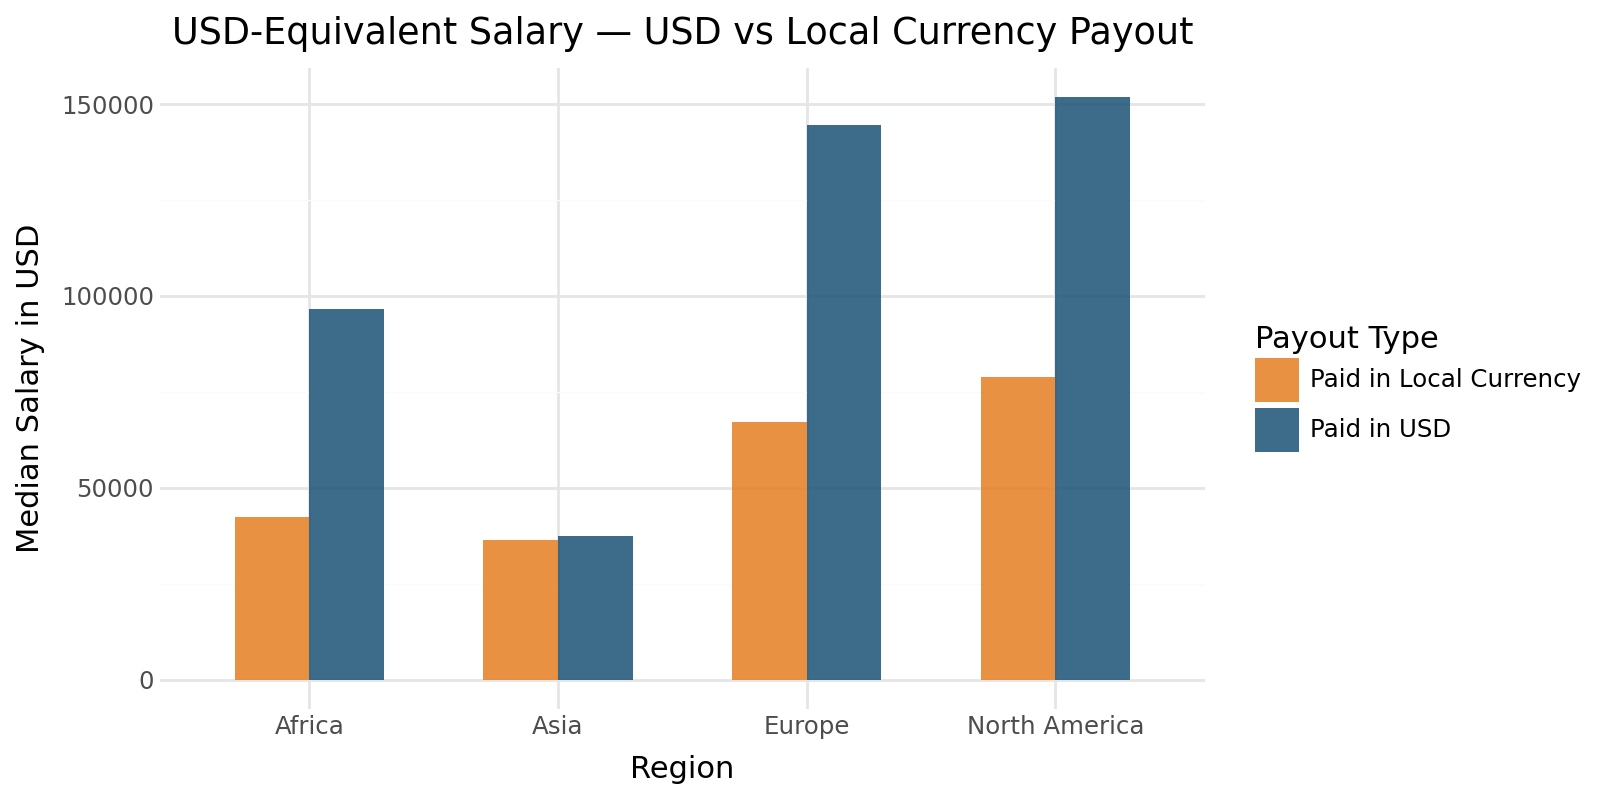

In [163]:
#  Visualise currency payout impact 
h = (ggplot(usd_vs_local,
        aes(x='continent', y='median', fill='paid_in_usd'))
+ geom_col(position='dodge', alpha=0.85, width=0.6)
+ scale_fill_manual(values={
    'Paid in USD'           : '#1A5276',
    'Paid in Local Currency': '#E67E22'
  })
+ labs(
    title = 'USD-Equivalent Salary — USD vs Local Currency Payout',
    x     = 'Region',
    y     = 'Median Salary in USD',
    fill  = 'Payout Type'
  )
+ theme_minimal()
+ theme(figure_size=(8, 4))
)
h.save('USD_equivalent_versus_local_currency.png',# save plot
       dpi    = 300,          # high resolution
       width  = 14,
       height = 8)

print("Plot saved successfully!")
h.show()


In [130]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import f_oneway, levene, shapiro, kruskal
import matplotlib.pyplot as plt
from plotnine import *

print("Libraries loaded successfully!")

Libraries loaded successfully!


## ANOVA TESTING

ANOVA = Analysis of Variance
It answers one question:

"Is the difference in salaries across groups statistically significant — or could it just be random chance?"

For this dataset, i can test:

Do salaries differ significantly across experience levels?
Do salaries differ significantly across regions?
Do salaries differ significantly across company sizes?

In [131]:
#  Check Normality Per Group 
print("=== NORMALITY TEST (Shapiro-Wilk) ===")
print("p > 0.05 = normally distributed ✅")
print("p < 0.05 = NOT normally distributed ❌")
print()

for level in ds2['experience_level'].unique():
    group = ds2[
        ds2['experience_level'] == level
    ]['salary_in_usd']
    
    # Shapiro-Wilk works best on samples under 5000
    sample = group.sample(min(1000, len(group)), random_state=42)
    stat, p = shapiro(sample)
    
    result = "✅ Normal" if p > 0.05 else "❌ Not Normal"
    print(f"{level:<20} | W={stat:.4f} | p={p:.6f} | {result}")

=== NORMALITY TEST (Shapiro-Wilk) ===
p > 0.05 = normally distributed ✅
p < 0.05 = NOT normally distributed ❌

Mid Level            | W=0.8840 | p=0.000000 | ❌ Not Normal
Senior Level         | W=0.9518 | p=0.000000 | ❌ Not Normal
Entry Level          | W=0.9576 | p=0.000000 | ❌ Not Normal
Executive Level      | W=0.9722 | p=0.002393 | ❌ Not Normal


In [132]:
# Check Homogeneity of Variance (Levene's Test) 
print("\n=== LEVENE'S TEST FOR EQUAL VARIANCES ===")
print("p > 0.05 = equal variances ✅ (ANOVA assumption met)")
print("p < 0.05 = unequal variances ❌ (use Welch ANOVA)")
print()

groups_exp = [
    ds2[ds2['experience_level'] == level]['salary_in_usd'].values
    for level in ds2['experience_level'].unique()
]

stat, p = levene(*groups_exp)
print(f"Levene Statistic : {stat:.4f}")
print(f"P-value          : {p:.6f}")
print("Result           :", "✅ Equal variances" if p > 0.05 else "❌ Unequal variances — use Welch ANOVA")


=== LEVENE'S TEST FOR EQUAL VARIANCES ===
p > 0.05 = equal variances ✅ (ANOVA assumption met)
p < 0.05 = unequal variances ❌ (use Welch ANOVA)

Levene Statistic : 11.8834
P-value          : 0.000000
Result           : ❌ Unequal variances — use Welch ANOVA


In [133]:
# One-Way ANOVA: Salary by Experience Level 
print("\n=== ONE-WAY ANOVA: SALARY BY EXPERIENCE LEVEL ===")
print("H0: All experience levels have the same mean salary")
print("H1: At least one experience level has a different mean salary")
print()

entry     = ds2[ds2['experience_level'] == 'Entry Level']['salary_in_usd']
mid       = ds2[ds2['experience_level'] == 'Mid Level']['salary_in_usd']
senior    = ds2[ds2['experience_level'] == 'Senior Level']['salary_in_usd']
executive = ds2[ds2['experience_level'] == 'Executive Level']['salary_in_usd']

f_stat, p_value = f_oneway(entry, mid, senior, executive)

print(f"F-Statistic : {f_stat:.4f}")
print(f"P-value     : {p_value:.6f}")
print()
if p_value < 0.05:
    print("✅ REJECT H0 — Experience level significantly affects salary")
    print("   At least one group has a meaningfully different mean salary")
else:
    print("❌ FAIL TO REJECT H0 — No significant salary difference")


=== ONE-WAY ANOVA: SALARY BY EXPERIENCE LEVEL ===
H0: All experience levels have the same mean salary
H1: At least one experience level has a different mean salary

F-Statistic : 240.7250
P-value     : 0.000000

✅ REJECT H0 — Experience level significantly affects salary
   At least one group has a meaningfully different mean salary


In [134]:
# One-Way ANOVA: Salary by Region 
print("\n=== ONE-WAY ANOVA: SALARY BY REGION ===")
print("H0: All regions have the same mean salary")
print("H1: At least one region has a different mean salary")
print()

africa    = ds2[ds2['continent'] == 'Africa']['salary_in_usd']
asia      = ds2[ds2['continent'] == 'Asia']['salary_in_usd']
na        = ds2[ds2['continent'] == 'North America']['salary_in_usd']
europe    = ds2[ds2['continent'] == 'Europe']['salary_in_usd']

f_stat_r, p_value_r = f_oneway(africa, asia, na, europe)

print(f"F-Statistic : {f_stat_r:.4f}")
print(f"P-value     : {p_value_r:.6f}")
print()
if p_value_r < 0.05:
    print("✅ REJECT H0 — Region significantly affects salary")
else:
    print("❌ FAIL TO REJECT H0 — No significant regional salary difference")


=== ONE-WAY ANOVA: SALARY BY REGION ===
H0: All regions have the same mean salary
H1: At least one region has a different mean salary

F-Statistic : 179.0503
P-value     : 0.000000

✅ REJECT H0 — Region significantly affects salary


In [135]:
#  One-Way ANOVA: Salary by Company Size 
print("\n=== ONE-WAY ANOVA: SALARY BY COMPANY SIZE ===")
print("H0: All company sizes pay the same mean salary")
print("H1: At least one company size pays differently")
print()

small  = ds2[ds2['company_size'] == 'Small']['salary_in_usd']
medium = ds2[ds2['company_size'] == 'Medium']['salary_in_usd']
large  = ds2[ds2['company_size'] == 'Large']['salary_in_usd']

f_stat_s, p_value_s = f_oneway(small, medium, large)

print(f"F-Statistic : {f_stat_s:.4f}")
print(f"P-value     : {p_value_s:.6f}")
print()
if p_value_s < 0.05:
    print("✅ REJECT H0 — Company size significantly affects salary")
else:
    print("❌ FAIL TO REJECT H0 — No significant difference by company size")


=== ONE-WAY ANOVA: SALARY BY COMPANY SIZE ===
H0: All company sizes pay the same mean salary
H1: At least one company size pays differently

F-Statistic : 30.6230
P-value     : 0.000000

✅ REJECT H0 — Company size significantly affects salary


In [136]:
#  Kruskal-Wallis Test (Non-parametric backup) 
# If normality assumption was violated — use this instead
print("\n=== KRUSKAL-WALLIS TEST (Non-Parametric ANOVA) ===")
print("Use this if Shapiro-Wilk showed data is NOT normally distributed")
print()

# By experience level
kw_stat_e, kw_p_e = kruskal(entry, mid, senior, executive)
print(f"Experience Level: H={kw_stat_e:.4f}, p={kw_p_e:.6f}",
      "✅ Significant" if kw_p_e < 0.05 else "❌ Not significant")

# By region
kw_stat_r, kw_p_r = kruskal(africa, asia, na, europe)
print(f"Region          : H={kw_stat_r:.4f}, p={kw_p_r:.6f}",
      "✅ Significant" if kw_p_r < 0.05 else "❌ Not significant")

# By company size
kw_stat_s, kw_p_s = kruskal(small, medium, large)
print(f"Company Size    : H={kw_stat_s:.4f}, p={kw_p_s:.6f}",
      "✅ Significant" if kw_p_s < 0.05 else "❌ Not significant")


=== KRUSKAL-WALLIS TEST (Non-Parametric ANOVA) ===
Use this if Shapiro-Wilk showed data is NOT normally distributed

Experience Level: H=786.8003, p=0.000000 ✅ Significant
Region          : H=617.1015, p=0.000000 ✅ Significant
Company Size    : H=73.6035, p=0.000000 ✅ Significant


In [137]:
# Tukey's Post-Hoc Test 
# Tells you WHICH specific pairs of groups differ significantly
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("\n=== TUKEY'S HSD POST-HOC TEST — EXPERIENCE LEVEL ===")
print("Shows WHICH experience levels have significantly different salaries")
print()

tukey_exp = pairwise_tukeyhsd(
    endog  = ds2['salary_in_usd'],
    groups = ds2['experience_level'],
    alpha  = 0.05
)
print(tukey_exp.summary())


=== TUKEY'S HSD POST-HOC TEST — EXPERIENCE LEVEL ===
Shows WHICH experience levels have significantly different salaries

              Multiple Comparison of Means - Tukey HSD, FWER=0.05               
     group1          group2       meandiff  p-adj    lower       upper    reject
--------------------------------------------------------------------------------
    Entry Level Executive Level 102998.3007   0.0  86996.0955 119000.5059   True
    Entry Level       Mid Level   35350.219   0.0  26029.8488  44670.5892   True
    Entry Level    Senior Level  71709.4141   0.0  62727.0706  80691.7576   True
Executive Level       Mid Level -67648.0817   0.0 -81803.8269 -53492.3366   True
Executive Level    Senior Level -31288.8866   0.0 -45224.3922  -17353.381   True
      Mid Level    Senior Level  36359.1951   0.0  31359.4905  41358.8997   True
--------------------------------------------------------------------------------


In [138]:
print("\n=== TUKEY'S HSD POST-HOC TEST — REGION ===")
print("Shows WHICH regions have significantly different salaries")
print()

tukey_region = pairwise_tukeyhsd(
    endog  = ds2['salary_in_usd'],
    groups = ds2['continent'],
    alpha  = 0.05
)
print(tukey_region.summary())


=== TUKEY'S HSD POST-HOC TEST — REGION ===
Shows WHICH regions have significantly different salaries

          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
group1     group2      meandiff  p-adj     lower        upper    reject
-----------------------------------------------------------------------
Africa          Asia -62653.9444 0.0056 -111620.0222 -13687.8667   True
Africa        Europe -27579.2762 0.2915  -67783.3701  12624.8178  False
Africa North America  46486.1564 0.0128    7150.7841  85821.5286   True
  Asia        Europe  35074.6683 0.0166    4557.1543  65592.1823   True
  Asia North America 109140.1008    0.0   79776.5008 138503.7008   True
Europe North America  74065.4325    0.0   65070.2449  83060.6202   True
-----------------------------------------------------------------------


Plot saved successfully!


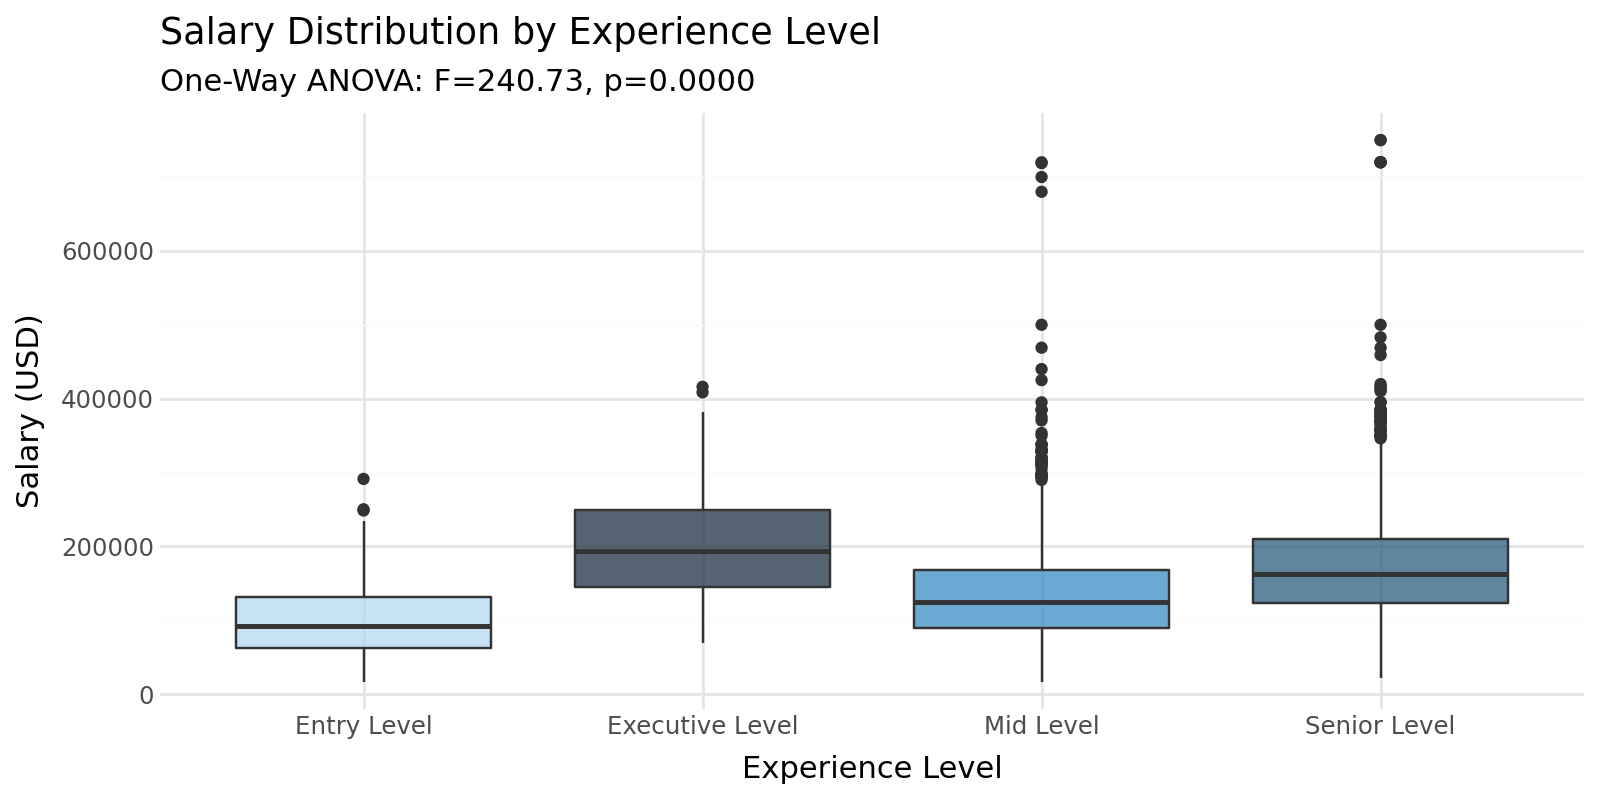

In [162]:
# Visualise ANOVA Results 
# Box plot per experience level
c = (ggplot(ds2,
        aes(x='experience_level',
            y='salary_in_usd',
            fill='experience_level'))
+ geom_boxplot(alpha=0.7)
+ scale_fill_manual(values={
    'Entry Level'    : '#AED6F1',
    'Mid Level'      : '#2E86C1',
    'Senior Level'   : '#1A5276',
    'Executive Level': '#0D2137'
  })
+ labs(
    title   = 'Salary Distribution by Experience Level',
    subtitle= f'One-Way ANOVA: F={f_stat:.2f}, p={p_value:.4f}',
    x       = 'Experience Level',
    y       = 'Salary (USD)'
  )
+ theme_minimal()
+ theme(figure_size=(8, 4), legend_position='none')
)
c.save('salary_distr_experience_level.png',# save plot
       dpi    = 300,          # high resolution
       width  = 14,
       height = 8)

print("Plot saved successfully!")
c.show()


Plot saved successfully!


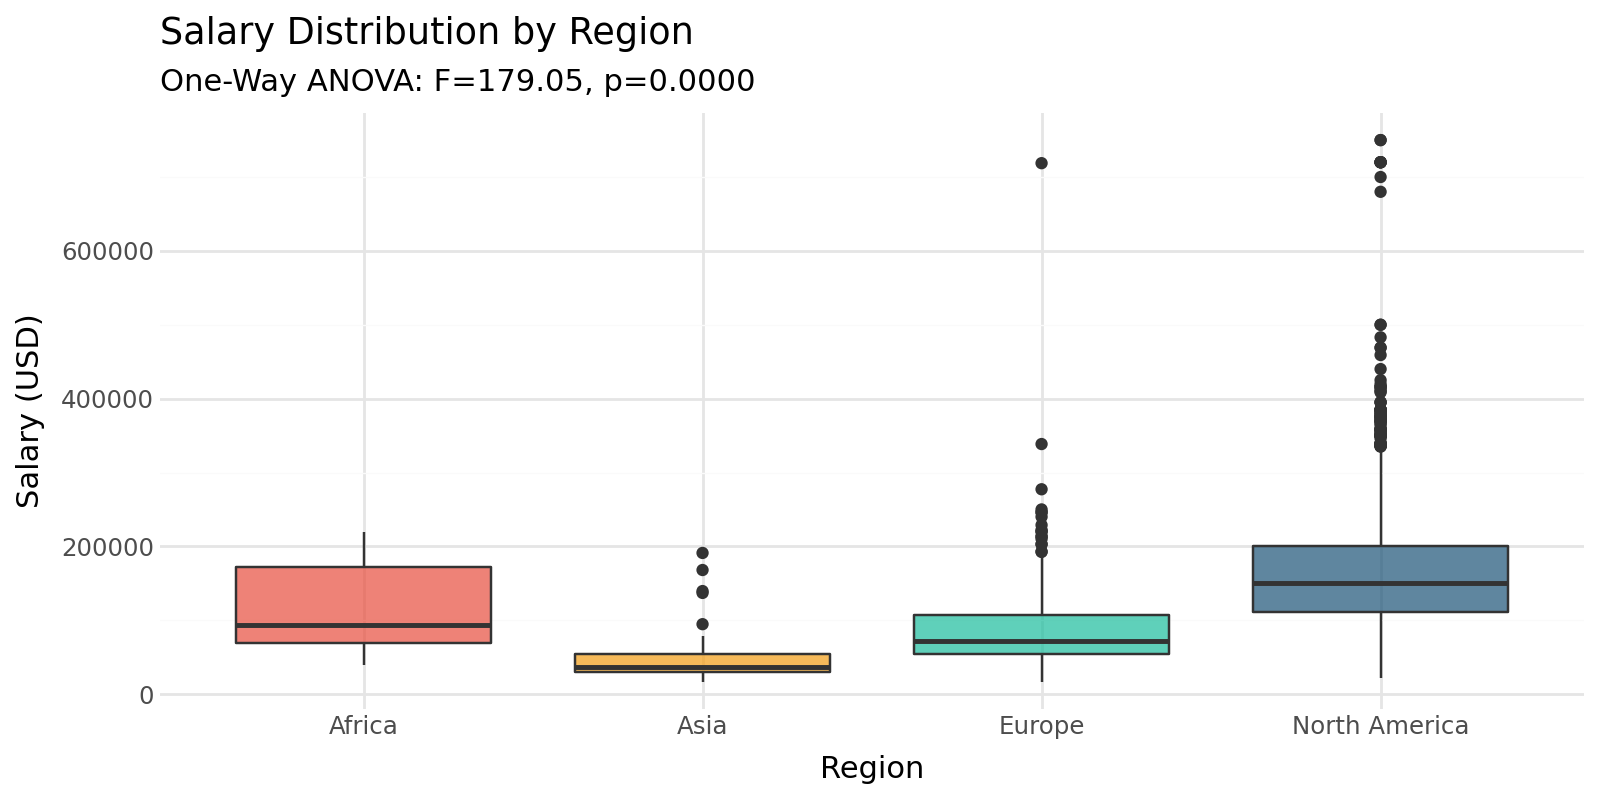

In [160]:
# Box plot per region
a = (ggplot(ds2,
        aes(x='continent',
            y='salary_in_usd',
            fill='continent'))
+ geom_boxplot(alpha=0.7)
+ scale_fill_manual(values={
    'Africa'       : '#E74C3C',
    'Asia'         : '#F39C12',
    'North America': '#1A5276',
    'Europe'       : '#1ABC9C'
  })
+ labs(
    title   = 'Salary Distribution by Region',
    subtitle= f'One-Way ANOVA: F={f_stat_r:.2f}, p={p_value_r:.4f}',
    x       = 'Region',
    y       = 'Salary (USD)'
  )
+ theme_minimal()
+ theme(figure_size=(8, 4), legend_position='none')
)
a.save('salary_distr_region.png',# save plot
       dpi    = 300,          # high resolution
       width  = 14,
       height = 8)

print("Plot saved successfully!")
a.show()


In [141]:
#  Complete ANOVA Summary Table 
anova_summary = pd.DataFrame({
    'Test'      : ['Experience Level', 'Region', 'Company Size'],
    'F-Statistic': [f_stat, f_stat_r, f_stat_s],
    'P-Value'   : [p_value, p_value_r, p_value_s],
    'Significant': [
        'Yes ✅' if p_value   < 0.05 else 'No ❌',
        'Yes ✅' if p_value_r < 0.05 else 'No ❌',
        'Yes ✅' if p_value_s < 0.05 else 'No ❌'
    ],
    'Decision' : [
        'Experience affects salary' if p_value   < 0.05 else 'No effect',
        'Region affects salary'     if p_value_r < 0.05 else 'No effect',
        'Company size affects salary' if p_value_s < 0.05 else 'No effect'
    ]
}).round(4)

print("\n=== COMPLETE ANOVA RESULTS SUMMARY ===")
print(anova_summary.to_string(index=False))


=== COMPLETE ANOVA RESULTS SUMMARY ===
            Test  F-Statistic  P-Value Significant                    Decision
Experience Level     240.7250      0.0       Yes ✅   Experience affects salary
          Region     179.0503      0.0       Yes ✅       Region affects salary
    Company Size      30.6230      0.0       Yes ✅ Company size affects salary


## DATA MODELLING

In [142]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (mean_squared_error, 
                              mean_absolute_error, 
                              r2_score)
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


since we are predicting prices. this is not a classification model lets start with regression model

In [143]:
# Prepare modelling dataframe 
df_model = ds2.copy()

# Encode all categorical columns
le = LabelEncoder()

cat_cols = ['experience_level', 'employment_type',
            'job_title', 'continent', 'company_size',
            'salary_currency']

for col in cat_cols:
    df_model[col + '_encoded'] = le.fit_transform(df_model[col])

# Define features and target
X = df_model[[
    'work_year',
    'experience_level_encoded',
    'employment_type_encoded',
    'remote_ratio',
    'company_size_encoded',
    'continent_encoded',
    'salary_currency_encoded'
]]

y = df_model['salary_in_usd']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFeatures used:")
for col in X.columns:
    print(f"  → {col}")

Features shape : (5685, 7)
Target shape   : (5685,)

Features used:
  → work_year
  → experience_level_encoded
  → employment_type_encoded
  → remote_ratio
  → company_size_encoded
  → continent_encoded
  → salary_currency_encoded


In [144]:
# ── Step 2 — Train/Test Split ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")

Training set : 4,548 rows
Test set     : 1,137 rows


In [145]:
# ── Step 3 — Scale For Linear Models Only ────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # ✅ transform only!

print("Scaling complete — applied to Linear and Ridge only")

Scaling complete — applied to Linear and Ridge only


In [146]:
# Model 1 — Linear Regression 
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr = lr_model.predict(X_test_scaled)

# Model 2 — Ridge Regression 
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge_train = ridge_model.predict(X_train_scaled)
y_pred_ridge = ridge_model.predict(X_test_scaled)

#  Model 3 — Lasso Regression 
lasso_model = Lasso(alpha=1.0, random_state=42, max_iter=5000)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso_train = lasso_model.predict(X_train_scaled)
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Model 4 — Decision Tree 
dt_model = DecisionTreeRegressor(
    max_depth    = 10,
    random_state = 42
)
dt_model.fit(X_train, y_train)
y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt = dt_model.predict(X_test)

# Model 5 — Random Forest 
rf_model = RandomForestRegressor(
    n_estimators = 100,
    max_depth    = 10,
    random_state = 42,
    n_jobs       = -1
)
rf_model.fit(X_train, y_train)
y_pred_rf_train= rf_model.predict(X_train)
y_pred_rf = rf_model.predict(X_test)

#  Model 6 — Gradient Boosting 
gb_model = GradientBoostingRegressor(
    n_estimators  = 100,
    max_depth     = 5,
    learning_rate = 0.1,
    random_state  = 42
)
gb_model.fit(X_train, y_train)
y_pred_gb_train = gb_model.predict(X_train)
y_pred_gb = gb_model.predict(X_test)

print("All 6 models trained successfully!")

All 6 models trained successfully!


In [147]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

def evaluate(name, y_train, y_pred_train, y_test, y_pred_test):
    return {
        'Model'       : name,
        'Train R²'    : round(r2_score(y_train, y_pred_train), 4),
        'Test R²'     : round(r2_score(y_test, y_pred_test), 4),
        'Train RMSE'  : round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2),
        'Test RMSE'   : round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 2),
        'Train MAE'   : round(mean_absolute_error(y_train, y_pred_train), 2),
        'Test MAE'    : round(mean_absolute_error(y_test, y_pred_test), 2),
    }

results = pd.DataFrame([
    evaluate('Linear Regression',
             y_train, y_pred_lr_train,
             y_test,  y_pred_lr),
    evaluate('Ridge Regression',
             y_train, y_pred_ridge_train,
             y_test,  y_pred_ridge),
    evaluate('Lasso Regression',
             y_train, y_pred_lasso_train,
             y_test,  y_pred_lasso),
    evaluate('Decision Tree',
             y_train, y_pred_dt_train,
             y_test,  y_pred_dt),
    evaluate('Random Forest',
             y_train, y_pred_rf_train,
             y_test,  y_pred_rf),
    evaluate('Gradient Boosting',
             y_train, y_pred_gb_train,
             y_test,  y_pred_gb),
]).sort_values('Test R²', ascending=False)

print("=== TRAIN vs TEST PERFORMANCE — ALL MODELS ===")
print(results.to_string(index=False))

=== TRAIN vs TEST PERFORMANCE — ALL MODELS ===
            Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE
Gradient Boosting    0.2242   0.1685    63675.37   62009.85   46236.34  47778.06
    Random Forest    0.2241   0.1658    63679.66   62110.83   46304.70  47909.76
    Decision Tree    0.2241   0.1602    63679.07   62319.91   46174.77  48003.95
Linear Regression    0.1577   0.1214    66346.30   63742.96   49068.10  48961.54
 Ridge Regression    0.1577   0.1214    66346.30   63742.67   49068.10  48961.10
 Lasso Regression    0.1577   0.1214    66346.30   63742.84   49068.12  48961.35


In [148]:
from sklearn.model_selection import cross_val_score

# Run CV on Random Forest and Gradient Boosting and Decision tree
for name, model in [
    ('Random Forest',     rf_model),
    ('Gradient Boosting', gb_model),
    ('Decision Tree', dt_model)
]:
    cv_scores = cross_val_score(
        model, X, y,
        cv      = 5,
        scoring = 'r2',
        n_jobs  = -1
    )
    print(f"\n{name} — 5-Fold CV R² Scores:")
    print(f"  Per fold : {cv_scores.round(4)}")
    print(f"  Mean R²  : {cv_scores.mean():.4f}")
    print(f"  Std R²   : {cv_scores.std():.4f}")


Random Forest — 5-Fold CV R² Scores:
  Per fold : [0.1725 0.1357 0.116  0.1416 0.3039]
  Mean R²  : 0.1740
  Std R²   : 0.0675

Gradient Boosting — 5-Fold CV R² Scores:
  Per fold : [0.1748 0.1358 0.1184 0.1436 0.2983]
  Mean R²  : 0.1742
  Std R²   : 0.0647

Decision Tree — 5-Fold CV R² Scores:
  Per fold : [0.1682 0.1332 0.1137 0.1393 0.304 ]
  Mean R²  : 0.1717
  Std R²   : 0.0684


Gradient Boosting wins by 0.0002

In [149]:
# Gradient Boosting is our champion
champion_model = gb_model

# Fit on training data
champion_model.fit(X_train, y_train)

# Predict on test data
y_pred_test  = champion_model.predict(X_test)
y_pred_train = champion_model.predict(X_train)

print(f"Train R² : {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R²  : {r2_score(y_test,  y_pred_test):.4f}")
print(f"Test RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_test)):,.0f}")
print(f"Test MAE : ${mean_absolute_error(y_test, y_pred_test):,.0f}")

Train R² : 0.2242
Test R²  : 0.1685
Test RMSE: $62,010
Test MAE : $47,778


=== TOP 15 FEATURES ===
                 Feature  Importance
 salary_currency_encoded    0.435256
experience_level_encoded    0.424976
               work_year    0.041683
       continent_encoded    0.038222
            remote_ratio    0.029019
    company_size_encoded    0.016051
 employment_type_encoded    0.014793
Plot saved successfully!


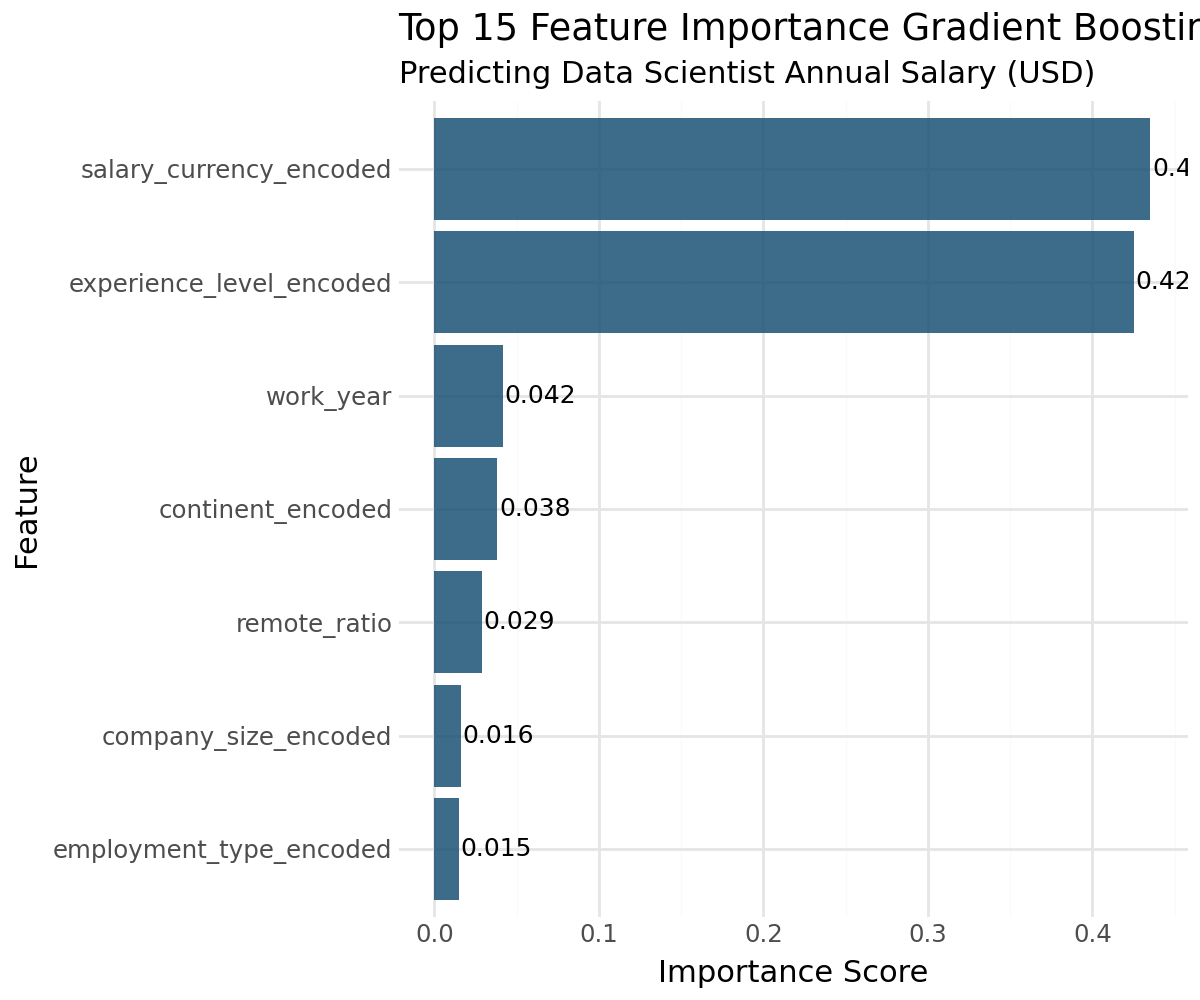

In [161]:
from plotnine import *

# Get feature importance from Gradient Boosting
importance_df = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': champion_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Top 15 only — avoid cluttered chart
top15 = importance_df.head(15)

print("=== TOP 15 FEATURES ===")
print(top15.to_string(index=False))

# Plot
k =(ggplot(top15,
        aes(x='reorder(Feature, Importance)',
            y='Importance'))
+ geom_col(fill='#1A5276', alpha=0.85)
+ geom_text(aes(label='Importance.round(3)'),
            ha='left', size=9, nudge_y=0.001)
+ coord_flip()
+ labs(
    title   = 'Top 15 Feature Importance Gradient Boosting',
    subtitle= 'Predicting Data Scientist Annual Salary (USD)',
    x       = 'Feature',
    y       = 'Importance Score'
  )
+ theme_minimal()
+ theme(figure_size=(6, 5))
)
k.save('Top_Feature_Importance_Gradient_Boosting.png',# save plot
       dpi    = 300,          # high resolution
       width  = 14,
       height = 8)

print("Plot saved successfully!")
k.show()


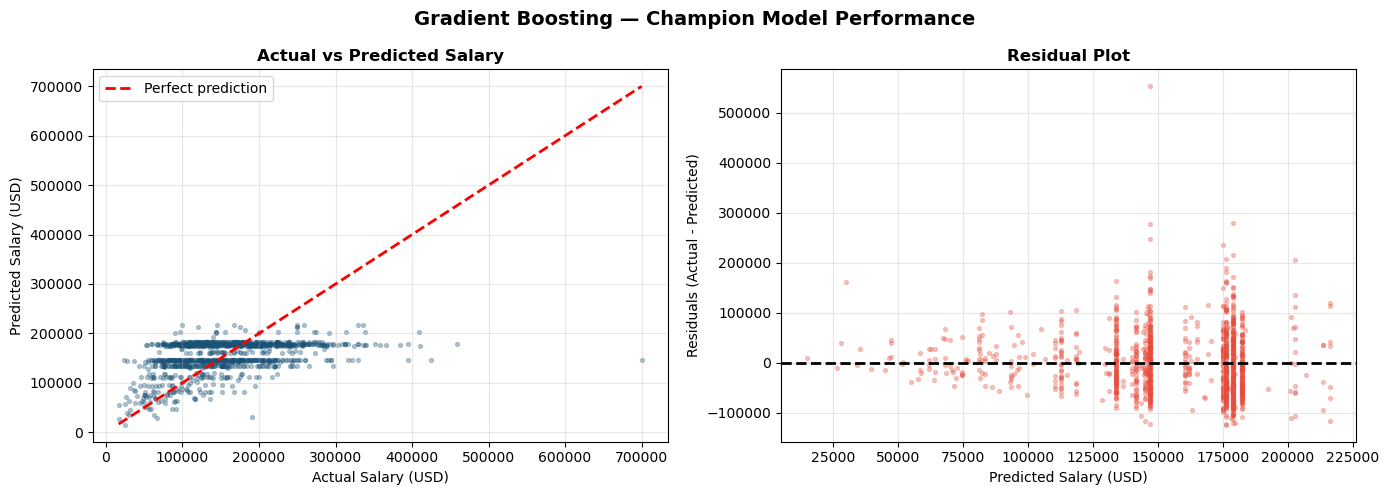

In [151]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Scatter: actual vs predicted
axes[0].scatter(y_test, y_pred_test,
                alpha=0.3, s=8, color='#1A5276')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title('Actual vs Predicted Salary',
                   fontweight='bold')
axes[0].set_xlabel('Actual Salary (USD)')
axes[0].set_ylabel('Predicted Salary (USD)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2 — Residuals
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals,
                alpha=0.3, s=8, color='#E74C3C')
axes[1].axhline(y=0, color='black',
                linestyle='--', linewidth=2)
axes[1].set_title('Residual Plot',
                   fontweight='bold')
axes[1].set_xlabel('Predicted Salary (USD)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].grid(alpha=0.3)

plt.suptitle('Gradient Boosting — Champion Model Performance',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [152]:
# Add predictions back to test records 
df_test = ds2.loc[y_test.index].copy()  
df_test['predicted_salary'] = y_pred_test
df_test['actual_salary']    = y_test.values

#  Average predicted salary by region 
avg_by_region = (df_test
    .groupby('continent')                              
    .agg(
        actual_mean    = ('actual_salary',    'mean'),
        predicted_mean = ('predicted_salary', 'mean'),
        count          = ('predicted_salary', 'count')
    )
    .reset_index()
    .round(0)
    .sort_values('predicted_mean', ascending=False))

print("=== PREDICTED vs ACTUAL SALARY BY REGION ===")
print(avg_by_region.to_string(index=False))

=== PREDICTED vs ACTUAL SALARY BY REGION ===
    continent  actual_mean  predicted_mean  count
North America     160179.0        160677.0   1047
       Africa     123733.0        143427.0      3
       Europe      91660.0         85227.0     79
         Asia      67701.0         55363.0      8


In [153]:
# Average predicted salary by region AND experience level
avg_by_exp = (df_test
    .groupby(['continent', 'experience_level'])
    .agg(
        actual_mean    = ('actual_salary',    'mean'),
        predicted_mean = ('predicted_salary', 'mean'),
        count          = ('predicted_salary', 'count')
    )
    .reset_index()
    .round(0))

# Pivot tables
pivot_actual = avg_by_exp.pivot(
    index='experience_level', columns='continent',
    values='actual_mean')

pivot_predicted = avg_by_exp.pivot(
    index='experience_level', columns='continent',
    values='predicted_mean')

print("\n=== ACTUAL MEAN SALARY BY EXPERIENCE & REGION ===")
print(pivot_actual.to_string())

print("\n=== PREDICTED MEAN SALARY BY EXPERIENCE & REGION ===")
print(pivot_predicted.to_string())


=== ACTUAL MEAN SALARY BY EXPERIENCE & REGION ===
continent           Africa     Asia    Europe  North America
experience_level                                            
Entry Level            NaN  29751.0   52941.0       113825.0
Executive Level        NaN      NaN  152220.0       221340.0
Mid Level          75600.0  54004.0   77995.0       146495.0
Senior Level      147800.0  98614.0  111630.0       171296.0

=== PREDICTED MEAN SALARY BY EXPERIENCE & REGION ===
continent           Africa     Asia    Europe  North America
experience_level                                            
Entry Level            NaN  34287.0   51740.0       109198.0
Executive Level        NaN      NaN  142074.0       202421.0
Mid Level         140152.0  59764.0   80521.0       141321.0
Senior Level      145064.0  56521.0   94168.0       177046.0


Plot saved successfully!


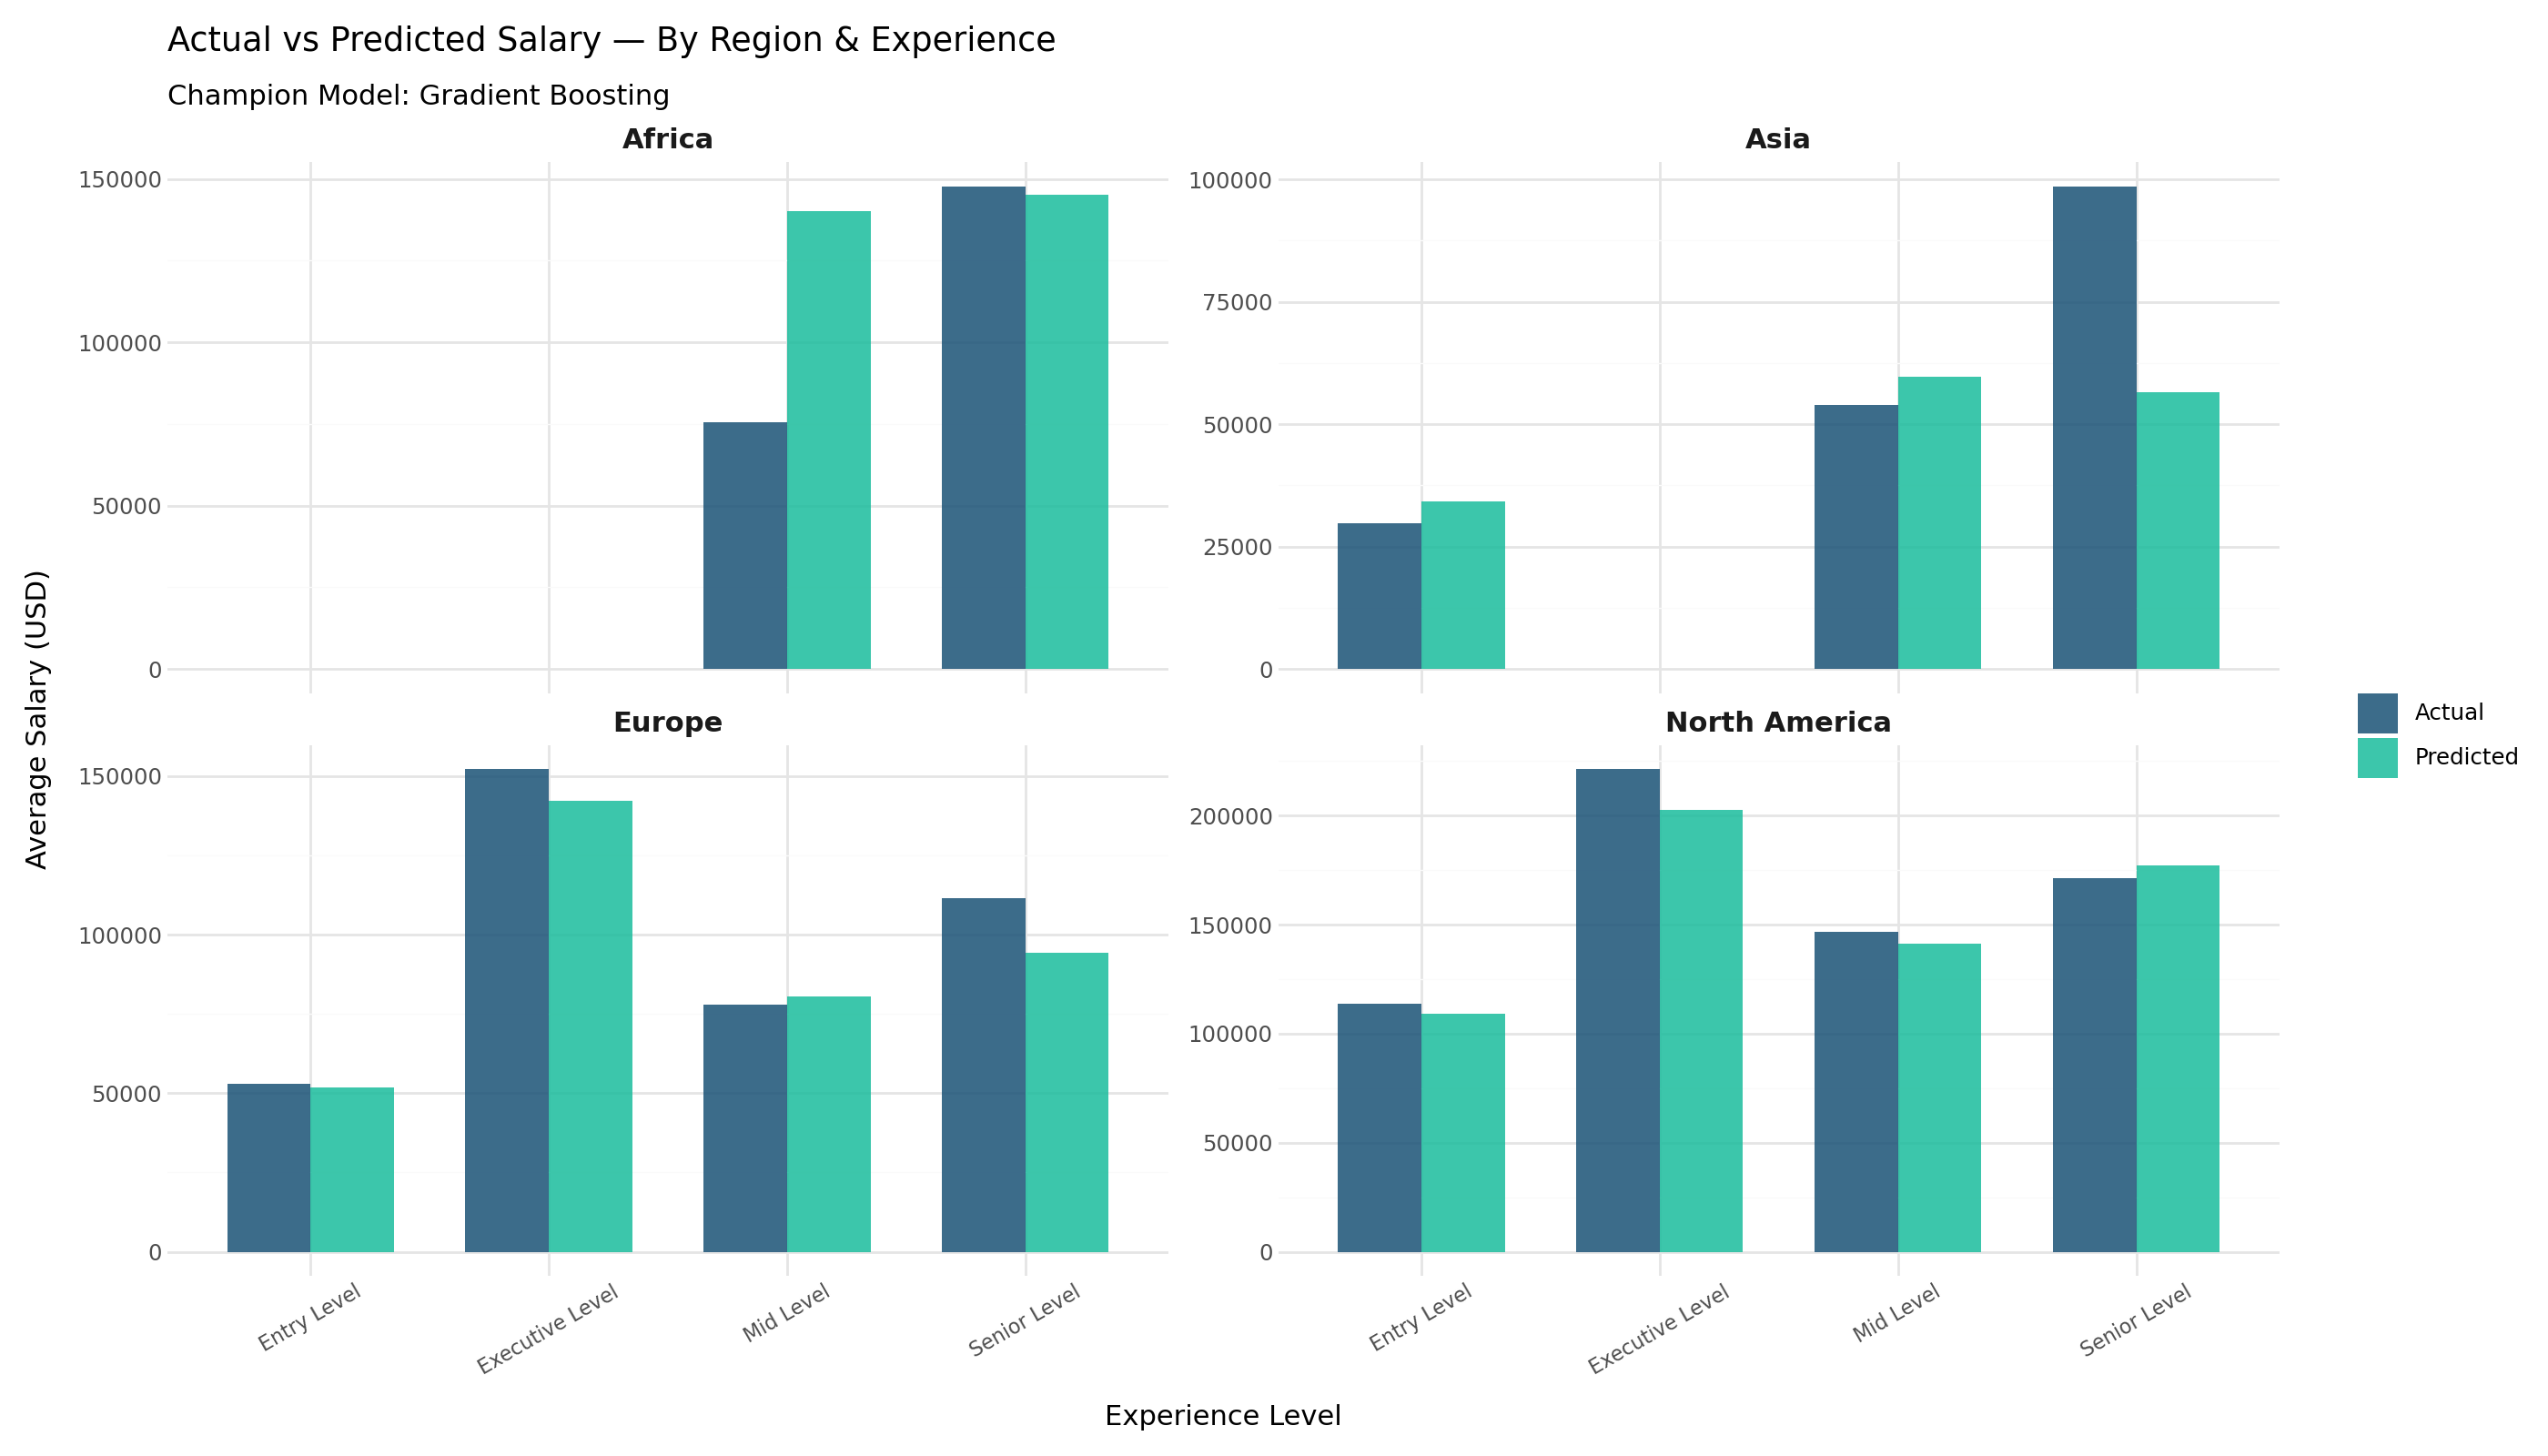

In [157]:
# Melt for comparison chart
actual_long = avg_by_exp[
    ['continent', 'experience_level', 'actual_mean']
].copy()
actual_long['Type'] = 'Actual'
actual_long = actual_long.rename(
    columns={'actual_mean': 'salary'}
)

pred_long = avg_by_exp[
    ['continent', 'experience_level', 'predicted_mean']
].copy()
pred_long['Type'] = 'Predicted'
pred_long = pred_long.rename(
    columns={'predicted_mean': 'salary'}
)

combined = pd.concat([actual_long, pred_long])

p = (ggplot(combined,
        aes(x='experience_level',
            y='salary',
            fill='Type'))
+ geom_col(position='dodge', alpha=0.85, width=0.7)
+ facet_wrap('~continent', scales='free_y')
+ scale_fill_manual(values={
    'Actual'   : '#1A5276',
    'Predicted': '#1ABC9C'
  })
+ labs(
    title    = 'Actual vs Predicted Salary — By Region & Experience',
    subtitle = 'Champion Model: Gradient Boosting',
    x        = 'Experience Level',
    y        = 'Average Salary (USD)',
    fill     = ''
  )
+ theme_minimal()
+ theme(
    figure_size = (14, 8),
    axis_text_x = element_text(rotation=30, size=8),
    strip_text  = element_text(size=11, face='bold')
  )
)
p.save('actual_vs_predicted_salary.png',# save plot
       dpi    = 300,          # high resolution
       width  = 14,
       height = 8)

print("Plot saved successfully!")
p.show()


## Conclusion


1. The Gradient Boosting model was selected as champion with a mean CV R² of 0.1742 marginally outperforming Random Forest (0.1740).
2. The relatively low R² reflects the inherent complexity of salary prediction — individual variation within job titles, negotiation, company pay bands and specific technical skills account for the 83% unexplained variance that aggregate features cannot capture.
3. Despite this, the predicted salary rankings across regions are directionally correct and consistent with EDA findings — North America dominates,followed by Europe, Asia and Africa.
4. The model is useful for understanding relative regional salary trends not for precise individual salary prediction.